# Final Evaluation Notebook — Hierarchical Concept-Based Explainable-by-Design Models

This notebook evaluates the final trained models on the same CUB-200-2011 test split.

It follows the course framing of explainability as an evaluation problem, not only a visualization problem. The notebook therefore separates:

- **predictive performance**: top-1/top-5 accuracy, F1, balanced accuracy, confusion matrices;
- **concept quality**: fine CUB attributes, parent evidence strengths, and parent presence diagnostics;
- **hierarchy coherence**: fine→part and part→region violations;
- **semantic mistake severity**: WordNet-derived family-like/genus-like distance;
- **faithfulness diagnostics**: concept removal and concept intervention;
- **plausibility/visual grounding**: Grad-CAM and occlusion maps, interpreted cautiously.

Important caveat: saliency/Grad-CAM maps are used only as qualitative plausibility checks. They do not prove explanation faithfulness, especially because CUB concept labels are image-level labels rather than spatial masks.


## 0. Installation

Set `RUN_ON_COLAB = True` when running in Google Colab. Leave it `False` when running locally from the project folder.


In [2]:
RUN_ON_COLAB = False # True = Colab, False = local

In [3]:
INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES and RUN_ON_COLAB:
    !pip install torch torchvision matplotlib pandas numpy Pillow tqdm scikit-learn nltk --quiet
    print('Dependencies installed.')
else:
    print('Skipping installation.')


Skipping installation.


## 1. Imports, paths, and configuration

This notebook expects the same directory structure used by the training notebooks:

```text
BASE_DIR/
  data/
    CUB_200_2011/
  processed/
    baseline_cbm_best.pt
    sol2_midcoarse_best.pt
    hier_learnable_weights_best.pt
    wordnet_cbm_best.pt
```

`CHECKPOINTS` is to be updated only if the trained checkpoint filenames change.


In [4]:
import os
import json
import math
import random
import tarfile
import urllib.request
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.linear_model import RidgeClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

if RUN_ON_COLAB:
    BASE_DIR = Path('/content')
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / 'data'
CUB_DIR = DATA_DIR / 'CUB_200_2011'
SAVE_DIR = BASE_DIR / 'processed'
EVAL_DIR = SAVE_DIR / 'final_evaluation'

DATA_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

CUB_URL = 'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz'
CUB_TGZ = DATA_DIR / 'CUB_200_2011.tgz'

CERTAINTY_THRESHOLD = 3
BATCH_SIZE = 64
NUM_WORKERS = 2 if RUN_ON_COLAB else 0
PIN_MEMORY = torch.cuda.is_available()
IMAGE_SIZE = 224

# Evaluation/debug options.
STRICT_CHECKPOINT_LOADING = True
RUN_GT_CONCEPT_PROBE = True
USE_WORDNET_TAXONOMY_IF_AVAILABLE = True

# Visual grounding: keep these qualitative and cautious.
GRADCAM_LAYER = 'layer3'  # layer3 generally localizes small parts better; layer4 is more semantic/coarse.
GRADCAM_USE_CONCEPT_LOGITS = True  # use pre-sigmoid fine logits to reduce saturation artifacts.
RUN_OCCLUSION_VISUAL_CHECK = True  # slower but often more faithful than gradients for one selected concept.
OCCLUSION_GRID = 7
OCCLUSION_PATCH = 48

# Learnable Hier-CBM aggregation mode.
# Keep False for checkpoints trained with the original sigmoid aggregation.
# True is only for explicitly retrained normalized-aggregation ablations.
USE_NORMALIZED_LEARNABLE_AGGREGATION_FOR_EVAL = False

# WordNet/taxonomic inference diagnostics.
RUN_WORDNET_BEAM_SEARCH = True
WORDNET_BEAM_WIDTHS = [1, 3, 5]  # 1 is equivalent to greedy; 3 is the recommended robust setting.
RUN_WORDNET_ORACLE_ROUTING = True
RUN_WORDNET_LOCAL_CONCEPT_QUALITY = True

# Checkpoint filenames used by the final training notebooks, with aliases for older runs.
CHECKPOINTS = {
    'Flat CBM': [SAVE_DIR / 'baseline_cbm_best.pt'],
    'Mean Hier-CBM': [SAVE_DIR / 'mean_matrix_best.pt', SAVE_DIR / 'sol2_midcoarse_best.pt'],
    'Learnable Hier-CBM': [
        SAVE_DIR / 'hier_learnable_weights_best.pt',
        SAVE_DIR / 'hier_learnable_weights_lighter_hierarchy_best.pt',
        SAVE_DIR / 'hier_learnable_weights_probe_experiments_best.pt',
    ],
    'Learnable Hier-CBM + Consistency': [
        SAVE_DIR / 'hier_learnable_consistency_best.pt',
        SAVE_DIR / 'hier_learnable_weights_consistency_best.pt',
    ],
    'WordNet Hier-CBM': [
        SAVE_DIR / 'wordnet_cbm_best_groupmask.pt',
        SAVE_DIR / 'wordnet_cbm_best.pt',
    ],
}

# Thresholds used to binarize concept probabilities for concept metrics and consistency.
FINE_THRESHOLD = 0.5
PART_THRESHOLD = 0.5
REGION_THRESHOLD = 0.5
PARENT_STRENGTH_THRESHOLD = 0.5

# WordNet-CBM hyperparameters. These must match hier_wordnet_cbm_final.ipynb.
BACKBONE_DIM = 2048
K_ROOT = 80
K_FAMILY = 50
K_GENUS = 30

# Hierarchy-conditioned concept relevance analysis.
RUN_HIERARCHY_CONCEPT_RELEVANCE = True
MI_TOP_K = 20
CONDITIONAL_MI_TOP_K = 10
MIN_CONDITIONAL_SAMPLES = 25
MIN_CONDITIONAL_CLASSES = 2
# Gradient-based taxonomic relevance can be slow on CPU. Set to None for the full test set.
RELEVANCE_MAX_SAMPLES = 1024


Device: cuda


## 2. Dataset download and annotation loading

This reproduces the same CUB preprocessing used by the training notebooks: all 312 attributes are kept, and annotations with certainty lower than the threshold are treated as absent.

In [5]:
def maybe_download_cub():
    os.makedirs(DATA_DIR, exist_ok=True)
    if os.path.isdir(CUB_DIR):
        print('CUB directory already exists.')
        return
    print('Downloading CUB-200-2011...')
    urllib.request.urlretrieve(CUB_URL, CUB_TGZ)
    print('Extracting...')
    with tarfile.open(CUB_TGZ, 'r:gz') as tar:
        tar.extractall(DATA_DIR)
    # Some mirrors put attributes.txt outside the attributes folder. Normalize if needed.
    src = os.path.join(DATA_DIR, 'attributes.txt')
    dst_dir = os.path.join(CUB_DIR, 'attributes')
    dst = os.path.join(dst_dir, 'attributes.txt')
    if os.path.exists(src) and not os.path.exists(dst):
        os.makedirs(dst_dir, exist_ok=True)
        os.replace(src, dst)
    print('Dataset ready.')

maybe_download_cub()

CUB directory already exists.


In [6]:
def load_txt(filename, col_names, sep=' '):
    return pd.read_csv(os.path.join(CUB_DIR, filename),
                       sep=sep, header=None, names=col_names)

images_df  = load_txt('images.txt',             ['img_id', 'filepath'])
labels_df  = load_txt('image_class_labels.txt', ['img_id', 'class_id'])
split_df   = load_txt('train_test_split.txt',   ['img_id', 'is_train'])
classes_df = load_txt("classes.txt", ["class_id", "class_name"])
attrs_df = load_txt("attributes/attributes.txt", ["attr_id", "attr_name"])

img_attr_df = pd.read_csv(
    Path(CUB_DIR) / "attributes/image_attribute_labels.txt",
    sep=r"\s+",
    header=None,
    usecols=[0, 1, 2, 3],
    names=["img_id", "attr_id", "is_present", "certainty"],
    engine="python"
)

img_attr_df = img_attr_df.astype({
    "img_id": int,
    "attr_id": int,
    "is_present": int,
    "certainty": int,
})

# Attribute names have format: has_part_property::value.
attrs_df[['raw_part', 'descriptor']] = attrs_df['attr_name'].str.split('::', expand=True)

master_df = images_df.merge(labels_df, on='img_id').merge(split_df, on='img_id')
master_df['label'] = master_df['class_id'] - 1

# Build binary concept matrix with certainty filtering.
img_attr_clean = img_attr_df.copy()

# If certainty is below threshold, treat the concept as absent instead of dropping the row.
img_attr_clean["is_present_filtered"] = np.where(
    img_attr_clean["certainty"] >= CERTAINTY_THRESHOLD,
    img_attr_clean["is_present"],
    0
)

concept_matrix = img_attr_clean.pivot_table(
    index="img_id",
    columns="attr_id",
    values="is_present_filtered",
    aggfunc="max",
    fill_value=0
)

# Force complete CUB indexing: 11788 images × 312 attributes.
all_img_ids = sorted(master_df["img_id"].unique())
all_attr_ids = sorted(attrs_df["attr_id"].unique())

concept_matrix = (
    concept_matrix
    .reindex(index=all_img_ids, columns=all_attr_ids, fill_value=0)
    .astype(np.float32)
)

N_CONCEPTS = len(attrs_df)
N_CLASSES = len(classes_df)

print('Images       :', len(master_df))
print('Train images :', int((master_df.is_train == 1).sum()))
print('Test images  :', int((master_df.is_train == 0).sum()))
print('Classes      :', N_CLASSES)
print('Attributes   :', N_CONCEPTS)

attrs_df.to_csv(os.path.join(SAVE_DIR, 'attrs_312.csv'), index=False)
classes_df.to_csv(os.path.join(SAVE_DIR, 'classes_df.csv'), index=False)
master_df.to_csv(os.path.join(SAVE_DIR, 'master_df.csv'), index=False)
concept_matrix.to_csv(os.path.join(SAVE_DIR, 'concept_matrix_312.csv'))

Images       : 11788
Train images : 5994
Test images  : 5794
Classes      : 200
Attributes   : 312


## 3. Attribute hierarchy construction

The visual-attribute hierarchy used here is:

```text
312 fine concepts → 18 anatomical parts → 4 coarse regions
```

In [7]:
def parse_part_from_attr(attr_name):
    name = attr_name.replace('has_', '').split('::')[0]
    part_map = {
        'bill_shape':       'bill',
        'bill_length':      'bill',
        'bill_color':       'bill',
        'wing_color':       'wing',
        'wing_shape':       'wing',
        'wing_pattern':     'wing',
        'upperparts_color': 'upperparts',
        'underparts_color': 'underparts',
        'breast_pattern':   'breast',
        'breast_color':     'breast',
        'back_color':       'back',
        'back_pattern':     'back',
        'tail_shape':       'tail',
        'upper_tail_color': 'tail',
        'under_tail_color': 'tail',
        'tail_pattern':     'tail',
        'head_pattern':     'head',
        'throat_color':     'throat',
        'eye_color':        'eye',
        'forehead_color':   'forehead',
        'nape_color':       'nape',
        'belly_color':      'belly',
        'belly_pattern':    'belly',
        'size':             'size',
        'shape':            'shape',
        'primary_color':    'primary',
        'leg_color':        'leg',
        'crown_color':      'crown',
    }
    return part_map.get(name, name)

REGION_MAP = {
    'bill':       'head',
    'crown':      'head',
    'eye':        'head',
    'forehead':   'head',
    'head':       'head',
    'nape':       'head',
    'throat':     'head',
    'back':       'body',
    'breast':     'body',
    'belly':      'body',
    'upperparts': 'body',
    'wing':       'body',
    'underparts': 'lower',
    'leg':        'lower',
    'tail':       'lower',
    'size':       'other',
    'shape':      'other',
    'primary':    'other',
}

def build_hierarchy(attrs_df):
    df = attrs_df.copy()
    df['part'] = df['attr_name'].apply(parse_part_from_attr)
    df['region'] = df['part'].map(REGION_MAP).fillna('other')

    parts = sorted(df['part'].unique())
    regions = sorted(df['region'].unique())
    part_to_idx = {p: i for i, p in enumerate(parts)}
    region_to_idx = {r: i for i, r in enumerate(regions)}

    M_fine = torch.zeros(len(parts), len(df))
    for _, row in df.iterrows():
        M_fine[part_to_idx[row['part']], int(row['attr_id']) - 1] = 1.0

    M_coarse = torch.zeros(len(regions), len(parts))
    part_to_region = torch.zeros(len(parts), dtype=torch.long)
    for part, region in REGION_MAP.items():
        if part in part_to_idx and region in region_to_idx:
            M_coarse[region_to_idx[region], part_to_idx[part]] = 1.0
            part_to_region[part_to_idx[part]] = region_to_idx[region]

    hierarchy_df = df[['attr_id', 'attr_name', 'part', 'region']].copy()
    return M_fine, M_coarse, parts, regions, part_to_idx, region_to_idx, part_to_region, hierarchy_df

(
    hier_M_fine,
    hier_M_coarse,
    hier_parts,
    hier_regions,
    hier_part_to_idx,
    hier_region_to_idx,
    hier_part_to_region,
    hierarchy_df,
) = build_hierarchy(attrs_df)

print('Fine attributes:', N_CONCEPTS)
print('Parts          :', len(hier_parts), hier_parts)
print('Regions        :', len(hier_regions), hier_regions)
print('\nAttributes per part:')
print(hierarchy_df.groupby(['region', 'part']).size())

Fine attributes: 312
Parts          : 18 ['back', 'belly', 'bill', 'breast', 'crown', 'eye', 'forehead', 'head', 'leg', 'nape', 'primary', 'shape', 'size', 'tail', 'throat', 'underparts', 'upperparts', 'wing']
Regions        : 4 ['body', 'head', 'lower', 'other']

Attributes per part:
region  part      
body    back          19
        belly         19
        breast        19
        upperparts    15
        wing          24
head    bill          27
        crown         15
        eye           14
        forehead      15
        head          11
        nape          15
        throat        15
lower   leg           15
        tail          40
        underparts    15
other   primary       15
        shape         14
        size           5
dtype: int64


## 4. Test dataset and dataloader

All models are evaluated on the same CUB test split.

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CUBDataset(Dataset):
    def __init__(self, master_df, concept_matrix, cub_dir, split='test', transform=None, return_meta=False):
        if split == 'train':
            self.df = master_df[master_df['is_train'] == 1].reset_index(drop=True)
        elif split == 'test':
            self.df = master_df[master_df['is_train'] == 0].reset_index(drop=True)
        else:
            self.df = master_df.reset_index(drop=True)
        self.concept_matrix = concept_matrix
        self.cub_dir = cub_dir
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = int(row['img_id'])
        img_path = os.path.join(self.cub_dir, 'images', row['filepath'])
        image = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = int(row['label'])
        concepts = torch.tensor(self.concept_matrix.loc[img_id].values, dtype=torch.float32)
        if self.return_meta:
            return image, label, concepts, img_id, row['filepath']
        return image, label, concepts


test_dataset = CUBDataset(master_df, concept_matrix, CUB_DIR, split='test', transform=test_transform, return_meta=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('Test samples:', len(test_dataset))

Test samples: 5794


## 5. Model definitions

These definitions mirror the training notebooks. If you modify the architecture in training, update the corresponding class here before loading the checkpoint.

In [9]:
class ConceptBottleneckModel(nn.Module):
    def __init__(self, n_concepts=312, n_classes=200):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        backbone.fc = nn.Linear(backbone.fc.in_features, n_concepts)
        self.backbone = backbone
        self.sigmoid = nn.Sigmoid()
        self.label_predictor = nn.Linear(n_concepts, n_classes)

    def forward(self, x, return_concepts=False, return_logits=False):
        fine_logits = self.backbone(x)
        fine = self.sigmoid(fine_logits)
        logits = self.label_predictor(fine)
        if return_logits:
            return logits, fine, fine_logits
        if return_concepts:
            return logits, fine
        return logits

    def classify_from_fine_concepts(self, fine):
        return self.label_predictor(fine)


class MeanHierarchicalCBM(nn.Module):
    def __init__(self, M_fine, M_coarse, n_concepts=312, n_classes=200):
        super().__init__()
        n_parts = M_fine.shape[0]
        n_regions = M_coarse.shape[0]
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        backbone.fc = nn.Linear(backbone.fc.in_features, n_concepts)
        self.backbone = backbone
        self.sigmoid_fine = nn.Sigmoid()
        self.register_buffer('M_fine', M_fine.float())
        self.register_buffer('M_coarse', M_coarse.float())
        self.register_buffer('cnt_parts', M_fine.sum(dim=1, keepdim=True).clamp(min=1).float())
        self.register_buffer('cnt_regions', M_coarse.sum(dim=1, keepdim=True).clamp(min=1).float())
        self.label_predictor = nn.Linear(n_parts + n_regions, n_classes)

    def aggregate_hierarchy(self, fine):
        mid = (fine @ self.M_fine.T) / self.cnt_parts.T
        coarse = (mid @ self.M_coarse.T) / self.cnt_regions.T
        return mid, coarse

    def forward(self, x, return_concepts=False, return_logits=False):
        fine_logits = self.backbone(x)
        fine = self.sigmoid_fine(fine_logits)
        mid, coarse = self.aggregate_hierarchy(fine)
        logits = self.label_predictor(torch.cat([mid, coarse], dim=1))
        if return_logits:
            return logits, fine, mid, coarse, fine_logits
        if return_concepts:
            return logits, fine, mid, coarse
        return logits

    def classify_from_fine_concepts(self, fine):
        mid, coarse = self.aggregate_hierarchy(fine)
        return self.label_predictor(torch.cat([mid, coarse], dim=1))


class LearnableHierarchicalCBM(nn.Module):
    def __init__(self, M_fine, M_coarse, part_to_region, n_concepts=312, n_classes=200,
                 normalized_aggregation=False):
        super().__init__()
        n_parts = M_fine.shape[0]
        n_regions = M_coarse.shape[0]
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        backbone.fc = nn.Linear(backbone.fc.in_features, n_concepts)
        self.backbone = backbone
        self.sigmoid_fine = nn.Sigmoid()
        self.register_buffer('M_fine', M_fine.float())
        self.register_buffer('M_coarse', M_coarse.float())
        self.register_buffer('cnt_parts', M_fine.sum(dim=1, keepdim=True).clamp(min=1).float())
        self.register_buffer('cnt_regions', M_coarse.sum(dim=1, keepdim=True).clamp(min=1).float())
        self.register_buffer('part_to_region', part_to_region.long())
        self.W_fine_mid = nn.Parameter(torch.ones_like(M_fine).float())
        self.W_mid_coarse = nn.Parameter(torch.ones_like(M_coarse).float())
        self.normalized_aggregation = normalized_aggregation
        self.label_predictor = nn.Sequential(
            nn.Linear(n_concepts + n_parts + n_regions, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes),
        )

    def aggregate_original(self, fine):
        # Matches the current trained checkpoint: masked learnable aggregation + sigmoid.
        # Interpret parent outputs as learned evidence activations, not calibrated probabilities.
        masked_fine_mid = self.W_fine_mid * self.M_fine
        mid = torch.sigmoid((fine @ masked_fine_mid.T) / self.cnt_parts.T)
        masked_mid_coarse = self.W_mid_coarse * self.M_coarse
        coarse = torch.sigmoid((mid @ masked_mid_coarse.T) / self.cnt_regions.T)
        return mid, coarse

    def aggregate_normalized_weighted_mean(self, fine):
        # Optional future/retrained variant: non-negative normalized weighted averages.
        w_fm = F.softplus(self.W_fine_mid) * self.M_fine
        denom_fm = w_fm.sum(dim=1, keepdim=True).T.clamp(min=1e-6)
        mid = (fine @ w_fm.T) / denom_fm
        w_mc = F.softplus(self.W_mid_coarse) * self.M_coarse
        denom_mc = w_mc.sum(dim=1, keepdim=True).T.clamp(min=1e-6)
        coarse = (mid @ w_mc.T) / denom_mc
        return mid, coarse

    def aggregate_hierarchy(self, fine):
        if self.normalized_aggregation:
            return self.aggregate_normalized_weighted_mean(fine)
        return self.aggregate_original(fine)

    # Backward-compatible alias used by older evaluation cells.
    def aggregate(self, fine):
        return self.aggregate_hierarchy(fine)

    def forward(self, x, return_concepts=False, return_logits=False):
        fine_logits = self.backbone(x)
        fine = self.sigmoid_fine(fine_logits)
        mid, coarse = self.aggregate_hierarchy(fine)
        logits = self.label_predictor(torch.cat([fine, mid, coarse], dim=1))
        if return_logits:
            return logits, fine, mid, coarse, fine_logits
        if return_concepts:
            return logits, fine, mid, coarse
        return logits

    def classify_from_fine_concepts(self, fine):
        mid, coarse = self.aggregate_hierarchy(fine)
        return self.label_predictor(torch.cat([fine, mid, coarse], dim=1))


class LocalConceptHead(nn.Module):
    """2048 -> local concept scores -> child logits, used by the WordNet taxonomic model."""
    def __init__(self, in_dim, n_local_concepts, n_children):
        super().__init__()
        self.concept_net = nn.Sequential(nn.Linear(in_dim, n_local_concepts), nn.Sigmoid())
        self.child_linear = nn.Linear(n_local_concepts, n_children)

    def forward(self, x):
        c = self.concept_net(x)
        return self.child_linear(c), c


class WordNetCBM(nn.Module):
    """Hierarchical classifier with local concept bottleneck heads.

    This is not a single global 312-concept CBM. It uses path-dependent local concept heads:
      root head      -> family-like group
      family head    -> genus-like group within the selected family-like group
      genus head     -> species within the selected genus-like group
    Therefore it participates in predictive and semantic-severity metrics, and has separate local
    concept-quality diagnostics, but it is not included in global fine/part/region CBM metrics.
    """
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.root_head = LocalConceptHead(BACKBONE_DIM, K_ROOT, N_FAMILIES)
        self.family_heads = nn.ModuleDict({
            str(fid): LocalConceptHead(BACKBONE_DIM, len(family_concept_masks[fid]), len(gids))
            for fid, gids in family_to_genera_map.items()
        })
        self.genus_heads = nn.ModuleDict({
            str(gid): LocalConceptHead(BACKBONE_DIM, len(genus_concept_masks[gid]), len(sp_ids))
            for gid, sp_ids in genus_to_species_map.items()
        })

    def features(self, x):
        return self.backbone(x).flatten(1)

    def forward_train(self, x, true_family, true_genus):
        """Teacher-forced routing used for oracle diagnostics and local concept quality."""
        feats = self.features(x)
        B = feats.shape[0]
        family_logits, root_concepts = self.root_head(feats)

        genus_logits = torch.full((B, N_GENERA), -1e4, device=feats.device)
        fam_concept_preds = {}
        for fid in true_family.unique().tolist():
            fid = int(fid)
            m = true_family == fid
            g_log, fam_c = self.family_heads[str(fid)](feats[m])
            fam_concept_preds[fid] = (m, fam_c)
            for li, gid in enumerate(family_to_genera_map[fid]):
                genus_logits[m, gid] = g_log[:, li]

        species_logits = torch.full((B, N_CLASSES), -1e4, device=feats.device)
        gen_concept_preds = {}
        for gid in true_genus.unique().tolist():
            gid = int(gid)
            m = true_genus == gid
            s_log, gen_c = self.genus_heads[str(gid)](feats[m])
            gen_concept_preds[gid] = (m, gen_c)
            for li, sid in enumerate(genus_to_species_map[gid]):
                species_logits[m, sid] = s_log[:, li]
        return family_logits, genus_logits, species_logits, root_concepts, fam_concept_preds, gen_concept_preds

    def forward_greedy_logits(self, x):
        feats = self.features(x)
        B = feats.shape[0]
        family_logits, _ = self.root_head(feats)
        pred_fam = family_logits.argmax(dim=1)

        genus_logits = torch.full((B, N_GENERA), -1e4, device=feats.device)
        for fid in pred_fam.unique().tolist():
            fid = int(fid)
            m = pred_fam == fid
            g_log, _ = self.family_heads[str(fid)](feats[m])
            for li, gid in enumerate(family_to_genera_map[fid]):
                genus_logits[m, gid] = g_log[:, li]
        pred_gen = genus_logits.argmax(dim=1)

        species_logits = torch.full((B, N_CLASSES), -1e4, device=feats.device)
        for gid in pred_gen.unique().tolist():
            gid = int(gid)
            m = pred_gen == gid
            s_log, _ = self.genus_heads[str(gid)](feats[m])
            for li, sid in enumerate(genus_to_species_map[gid]):
                species_logits[m, sid] = s_log[:, li]
        return family_logits, genus_logits, species_logits

    @torch.no_grad()
    def forward_greedy(self, x):
        family_logits, genus_logits, species_logits = self.forward_greedy_logits(x)
        return family_logits.argmax(dim=1), genus_logits.argmax(dim=1), species_logits.argmax(dim=1)

    def forward_beam_logits(self, x, beam_width=3):
        """Return dense family/genus/species score tensors for beam-search inference.

        Scores are log-probability sums along explored paths. Non-explored species receive a very
        negative score. beam_width=1 is effectively greedy.
        """
        feats = self.features(x)
        B = feats.shape[0]
        device_ = feats.device
        family_logits, _ = self.root_head(feats)
        family_logp = F.log_softmax(family_logits, dim=1)

        dense_genus_scores = torch.full((B, N_GENERA), -1e9, device=device_)
        dense_species_scores = torch.full((B, N_CLASSES), -1e9, device=device_)
        best_family = torch.zeros(B, dtype=torch.long, device=device_)
        best_genus = torch.zeros(B, dtype=torch.long, device=device_)

        for b in range(B):
            kf = min(beam_width, family_logp.shape[1])
            fam_vals, fam_ids = torch.topk(family_logp[b], k=kf)
            genus_beams = []
            for fam_score, fid_t in zip(fam_vals, fam_ids):
                fid = int(fid_t.item())
                g_logits, _ = self.family_heads[str(fid)](feats[b:b+1])
                g_logp = F.log_softmax(g_logits[0], dim=0)
                kg = min(beam_width, g_logp.numel())
                g_vals, local_gids = torch.topk(g_logp, k=kg)
                for g_score, local_gid_t in zip(g_vals, local_gids):
                    local_gid = int(local_gid_t.item())
                    gid = family_to_genera_map[fid][local_gid]
                    total = fam_score + g_score
                    dense_genus_scores[b, gid] = torch.maximum(dense_genus_scores[b, gid], total)
                    genus_beams.append((total, fid, gid))
            genus_beams = sorted(genus_beams, key=lambda t: float(t[0]), reverse=True)[:beam_width]
            species_beams = []
            for path_score, fid, gid in genus_beams:
                s_logits, _ = self.genus_heads[str(gid)](feats[b:b+1])
                s_logp = F.log_softmax(s_logits[0], dim=0)
                ks = min(beam_width, s_logp.numel())
                s_vals, local_sids = torch.topk(s_logp, k=ks)
                for s_score, local_sid_t in zip(s_vals, local_sids):
                    local_sid = int(local_sid_t.item())
                    sid = genus_to_species_map[gid][local_sid]
                    total = path_score + s_score
                    dense_species_scores[b, sid] = torch.maximum(dense_species_scores[b, sid], total)
                    species_beams.append((total, fid, gid, sid))
            if species_beams:
                best = max(species_beams, key=lambda t: float(t[0]))
                best_family[b] = best[1]
                best_genus[b] = best[2]
        # family logits are unchanged; dense genus/species contain beam path scores.
        return family_logits, dense_genus_scores, dense_species_scores, best_family, best_genus


### Optional WordNet-style taxonomic model

This block is optional. It is included so the checkpoint trained in the WordNet notebook can be evaluated in the same notebook. If the checkpoint or required objects are not available, the rest of the notebook still works.

In [10]:
def class_name_to_readable(name):
    return name.split('.', 1)[-1].replace('_', ' ')

def fallback_genus_family(class_name):
    # Weak fallback from the common CUB class name. This is not biological taxonomy.
    readable = class_name_to_readable(class_name).lower()
    tokens = readable.split()
    genus = tokens[-1] if tokens else 'unknown'
    family = (tokens[-2] if len(tokens) > 1 else genus) + ' (fallback)'
    return genus, family

def try_build_wordnet_taxonomy(classes_df):
    try:
        import nltk
        from nltk.corpus import wordnet as wn
        try:
            wn.synsets('bird', pos=wn.NOUN)
        except LookupError:
            nltk.download('wordnet', quiet=True)
            nltk.download('omw-1.4', quiet=True)
        _ = wn.synsets('bird', pos=wn.NOUN)
    except Exception as e:
        print('WordNet taxonomy unavailable; using weak name-token fallback. Reason:', repr(e))
        return None

    too_general = {
        'bird.n.01', 'fowl.n.01', 'fowl.n.02',
        'vertebrate.n.01', 'chordate.n.01', 'animal.n.01', 'organism.n.01',
        'living_thing.n.01', 'whole.n.02', 'object.n.01',
        'physical_entity.n.01', 'entity.n.01',
    }

    def get_bird_synset(class_name):
        raw = class_name.split('.', 1)[-1].lower().replace('_', ' ')
        candidates = [raw, ' '.join(raw.split()[-2:]), raw.split()[-1]]
        for query in candidates:
            synsets = wn.synsets(query.replace(' ', '_'), pos=wn.NOUN)
            for s in synsets:
                ancestors = set(h.name() for h in s.closure(lambda x: x.hypernyms()))
                if any('bird' in h or 'fowl' in h for h in ancestors):
                    return s
        return None

    def get_genus_family(synset):
        if synset is None:
            return None, None
        genus = synset.lemmas()[0].name().replace('_', ' ')
        hypernyms = synset.hypernyms()
        if not hypernyms:
            return genus, genus
        parent = hypernyms[0]
        if parent.name() in too_general:
            return genus, genus
        family = parent.lemmas()[0].name().replace('_', ' ')
        return genus, family

    taxonomy = {}
    missing = []
    for _, row in classes_df.iterrows():
        sp0 = int(row['class_id']) - 1
        name = str(row['class_name'])
        syn = get_bird_synset(name)
        if syn is None:
            missing.append(name)
            genus, family = fallback_genus_family(name)
        else:
            genus, family = get_genus_family(syn)
        taxonomy[sp0] = {'genus': genus, 'family': family, 'name': name}
    print(f'WordNet taxonomy found for approximately {N_CLASSES - len(missing)}/{N_CLASSES} classes.')
    if missing:
        print('Fallback examples:', missing[:5])
    return taxonomy

if USE_WORDNET_TAXONOMY_IF_AVAILABLE:
    class_taxonomy = try_build_wordnet_taxonomy(classes_df)
else:
    class_taxonomy = None

TAXONOMY_SOURCE = 'WordNet family-like/genus-like + fallback'
if class_taxonomy is None:
    TAXONOMY_SOURCE = 'weak name-token fallback'
    class_taxonomy = {}
    for _, row in classes_df.iterrows():
        sp = int(row['class_id']) - 1
        genus, family = fallback_genus_family(row['class_name'])
        class_taxonomy[sp] = {'genus': genus, 'family': family, 'name': row['class_name']}

all_genera = sorted(set(v['genus'] for v in class_taxonomy.values()))
all_families = sorted(set(v['family'] for v in class_taxonomy.values()))
genus_to_id = {g: i for i, g in enumerate(all_genera)}
family_to_id = {f: i for i, f in enumerate(all_families)}

species_to_genus = {}
species_to_family = {}
genus_to_family_map = {}
family_to_genera_map = {}
genus_to_species_map = {}
family_to_species_map = {}

# Store species IDs as 0-indexed everywhere in this evaluation notebook.
for sp0, info in class_taxonomy.items():
    gid = genus_to_id[info['genus']]
    fid = family_to_id[info['family']]
    species_to_genus[sp0] = gid
    species_to_family[sp0] = fid
    genus_to_family_map[gid] = fid
    family_to_genera_map.setdefault(fid, set()).add(gid)
    genus_to_species_map.setdefault(gid, []).append(sp0)
    family_to_species_map.setdefault(fid, []).append(sp0)
family_to_genera_map = {k: sorted(v) for k, v in family_to_genera_map.items()}
genus_to_species_map = {k: sorted(v) for k, v in genus_to_species_map.items()}
family_to_species_map = {k: sorted(v) for k, v in family_to_species_map.items()}

N_GENERA = len(all_genera)
N_FAMILIES = len(all_families)
print('Taxonomy source:', TAXONOMY_SOURCE)
print(f'Taxonomy: {N_FAMILIES} family-like groups -> {N_GENERA} genus-like groups -> {N_CLASSES} species')
print('Note: WordNet family/genus levels are semantic family-like/genus-like groups, not guaranteed strict biological taxonomy.')

# Local concept masks for the WordNet model. This matches hier_wordnet_cbm_final.ipynb:
# select concepts by variance of group-level mean concept vectors.
train_class_means = {}
for cid in range(1, N_CLASSES + 1):
    img_ids_c = master_df[(master_df['is_train'] == 1) & (master_df['class_id'] == cid)]['img_id']
    vals = concept_matrix.loc[list(img_ids_c)].values
    train_class_means[cid] = vals.mean(axis=0) if len(vals) else np.zeros(N_CONCEPTS)

def mean_for_class_ids(class_ids_1indexed):
    class_ids_1indexed = list(class_ids_1indexed)
    if len(class_ids_1indexed) == 0:
        return np.zeros(N_CONCEPTS)
    return np.stack([train_class_means[int(cid)] for cid in class_ids_1indexed]).mean(axis=0)

def top_discriminative_groups(groups_class_ids, n_select):
    valid_groups = [list(g) for g in groups_class_ids if len(g) > 0]
    if len(valid_groups) < 2:
        return list(range(min(n_select, N_CONCEPTS)))
    means = np.stack([mean_for_class_ids(g) for g in valid_groups])
    variances = means.var(axis=0)
    k = min(n_select, N_CONCEPTS)
    return sorted(np.argsort(variances)[-k:].tolist())

root_groups = [[sid + 1 for sid in family_to_species_map[fid]] for fid in range(N_FAMILIES)]
root_concept_mask = top_discriminative_groups(root_groups, K_ROOT)

family_concept_masks = {}
for fid, gids in family_to_genera_map.items():
    groups = [[sid + 1 for sid in genus_to_species_map[gid]] for gid in gids]
    family_concept_masks[fid] = top_discriminative_groups(groups, K_FAMILY)

genus_concept_masks = {}
for gid, sp_ids in genus_to_species_map.items():
    groups = [[sid + 1] for sid in sp_ids]
    genus_concept_masks[gid] = top_discriminative_groups(groups, K_GENUS)

with open(EVAL_DIR / 'taxonomy_and_wordnet_masks_eval.json', 'w') as f:
    json.dump({
        'taxonomy_source': TAXONOMY_SOURCE,
        'all_families': all_families,
        'all_genera': all_genera,
        'species_to_family': {str(k): int(v) for k, v in species_to_family.items()},
        'species_to_genus': {str(k): int(v) for k, v in species_to_genus.items()},
        'family_to_genera_map': {str(k): [int(x) for x in v] for k, v in family_to_genera_map.items()},
        'genus_to_species_map': {str(k): [int(x) for x in v] for k, v in genus_to_species_map.items()},
        'root_concept_mask': [int(x) for x in root_concept_mask],
        'family_concept_masks': {str(k): [int(x) for x in v] for k, v in family_concept_masks.items()},
        'genus_concept_masks': {str(k): [int(x) for x in v] for k, v in genus_concept_masks.items()},
    }, f, indent=2)
print(f'WordNet local concept masks: root={len(root_concept_mask)}, family avg={np.mean([len(v) for v in family_concept_masks.values()]):.1f}, genus avg={np.mean([len(v) for v in genus_concept_masks.values()]):.1f}')


WordNet taxonomy found for approximately 193/200 classes.
Fallback examples: ['022.Chuck_will_Widow', '044.Frigatebird', '046.Gadwall', '070.Green_Violetear', '105.Whip_poor_Will']
Taxonomy source: WordNet family-like/genus-like + fallback
Taxonomy: 62 family-like groups -> 109 genus-like groups -> 200 species
Note: WordNet family/genus levels are semantic family-like/genus-like groups, not guaranteed strict biological taxonomy.
WordNet local concept masks: root=80, family avg=50.0, genus avg=30.0


## 6. Instantiate and load checkpoints

Missing checkpoints are skipped automatically.

In [11]:
def resolve_checkpoint(paths):
    if isinstance(paths, (str, Path)):
        paths = [paths]
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return Path(paths[0]) if paths else None

def extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ['state_dict', 'model_state_dict', 'model']:
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
    return ckpt

def strip_module_prefix_if_needed(state):
    if not isinstance(state, dict):
        return state
    if all(k.startswith('module.') for k in state.keys()):
        return {k[len('module.'):]: v for k, v in state.items()}
    return state

def safe_load_state_dict(model, ckpt_paths, strict=STRICT_CHECKPOINT_LOADING):
    ckpt_path = resolve_checkpoint(ckpt_paths)
    if ckpt_path is None or not ckpt_path.exists():
        print(f'[skip] checkpoint not found. Tried: {ckpt_paths}')
        return False
    try:
        state = torch.load(ckpt_path, map_location=device, weights_only=True)
    except Exception:
        state = torch.load(ckpt_path, map_location=device)
    state = strip_module_prefix_if_needed(extract_state_dict(state))
    try:
        missing, unexpected = model.load_state_dict(state, strict=strict)
    except RuntimeError:
        if strict:
            print(f'[error] strict checkpoint loading failed for {ckpt_path}')
            raise
        missing, unexpected = model.load_state_dict(state, strict=False)
    print(f'[loaded] {ckpt_path}')
    if len(missing) > 0:
        print('  missing keys:', missing[:10], '...' if len(missing) > 10 else '')
    if len(unexpected) > 0:
        print('  unexpected keys:', unexpected[:10], '...' if len(unexpected) > 10 else '')
    if strict and (len(missing) > 0 or len(unexpected) > 0):
        raise RuntimeError('Checkpoint mismatch: missing/unexpected keys found under strict loading.')
    model.to(device).eval()
    return True

models_to_eval = {}

flat_model = ConceptBottleneckModel(N_CONCEPTS, N_CLASSES)
if safe_load_state_dict(flat_model, CHECKPOINTS['Flat CBM']):
    models_to_eval['Flat CBM'] = flat_model

mean_model = MeanHierarchicalCBM(hier_M_fine, hier_M_coarse, N_CONCEPTS, N_CLASSES)
if safe_load_state_dict(mean_model, CHECKPOINTS['Mean Hier-CBM']):
    models_to_eval['Mean Hier-CBM'] = mean_model

learnable_model = LearnableHierarchicalCBM(
    hier_M_fine, hier_M_coarse, hier_part_to_region, N_CONCEPTS, N_CLASSES,
    normalized_aggregation=USE_NORMALIZED_LEARNABLE_AGGREGATION_FOR_EVAL,
)
if safe_load_state_dict(learnable_model, CHECKPOINTS['Learnable Hier-CBM']):
    models_to_eval['Learnable Hier-CBM'] = learnable_model
    if not USE_NORMALIZED_LEARNABLE_AGGREGATION_FOR_EVAL:
        print('  Note: Learnable Hier-CBM uses original sigmoid aggregation to match the trained checkpoint.')

# Optional consistency model, if present.
cons_ckpt = resolve_checkpoint(CHECKPOINTS.get('Learnable Hier-CBM + Consistency', []))
if cons_ckpt is not None and cons_ckpt.exists():
    consistency_model = LearnableHierarchicalCBM(
        hier_M_fine, hier_M_coarse, hier_part_to_region, N_CONCEPTS, N_CLASSES,
        normalized_aggregation=USE_NORMALIZED_LEARNABLE_AGGREGATION_FOR_EVAL,
    )
    if safe_load_state_dict(consistency_model, CHECKPOINTS['Learnable Hier-CBM + Consistency']):
        models_to_eval['Learnable Hier-CBM + Consistency'] = consistency_model

# Optional WordNet taxonomic model. This must use the same taxonomy and group-level concept masks
# as the final WordNet training notebook, otherwise strict loading should fail.
wordnet_ckpt = resolve_checkpoint(CHECKPOINTS['WordNet Hier-CBM'])
if wordnet_ckpt.exists():
    try:
        wordnet_model = WordNetCBM()
        if safe_load_state_dict(wordnet_model, CHECKPOINTS['WordNet Hier-CBM']):
            models_to_eval['WordNet Hier-CBM'] = wordnet_model
    except Exception as e:
        print('[skip] WordNet Hier-CBM could not be loaded consistently:', repr(e))
else:
    print(f'[skip] WordNet Hier-CBM checkpoint not found: {wordnet_ckpt}')

print('\nModels available for evaluation:')
for name in models_to_eval:
    print(' -', name)


[loaded] c:\Users\elzia\Documents\torino\polito\05_semestre2\explainable_trustworthy_ai\progetto\github\ETAI-2025-26\processed\baseline_cbm_best.pt
[loaded] c:\Users\elzia\Documents\torino\polito\05_semestre2\explainable_trustworthy_ai\progetto\github\ETAI-2025-26\processed\mean_matrix_best.pt
[loaded] c:\Users\elzia\Documents\torino\polito\05_semestre2\explainable_trustworthy_ai\progetto\github\ETAI-2025-26\processed\hier_learnable_weights_best.pt
  Note: Learnable Hier-CBM uses original sigmoid aggregation to match the trained checkpoint.
[loaded] c:\Users\elzia\Documents\torino\polito\05_semestre2\explainable_trustworthy_ai\progetto\github\ETAI-2025-26\processed\wordnet_cbm_best_groupmask.pt

Models available for evaluation:
 - Flat CBM
 - Mean Hier-CBM
 - Learnable Hier-CBM
 - WordNet Hier-CBM


## 7. Common prediction collection

Each model is converted to a dictionary containing class predictions and concept predictions. Unavailable outputs are stored as `None`.

In [12]:
def aggregate_ground_truth(fine_gt, M_fine, M_coarse):
    """Return both continuous parent strength and binary parent presence.

    Strength: average fraction of active children, useful for MAE/MSE and thresholded-strength accuracy.
    Presence: whether any child is active, useful only as a diagnostic because all birds have most parts.
    """
    M_fine = M_fine.to(fine_gt.device)
    M_coarse = M_coarse.to(fine_gt.device)
    cnt_parts = M_fine.sum(dim=1, keepdim=True).clamp(min=1)
    cnt_regions = M_coarse.sum(dim=1, keepdim=True).clamp(min=1)

    part_strength = (fine_gt @ M_fine.T) / cnt_parts.T
    region_strength = (part_strength @ M_coarse.T) / cnt_regions.T

    part_presence = ((fine_gt @ M_fine.T) > 0).float()
    region_presence = ((part_presence @ M_coarse.T) > 0).float()
    return part_strength, region_strength, part_presence, region_presence

def taxonomy_targets_from_labels(labels):
    labels_np = labels.detach().cpu().numpy() if torch.is_tensor(labels) else np.asarray(labels)
    genus = np.array([species_to_genus[int(y)] for y in labels_np], dtype=np.int64)
    family = np.array([species_to_family[int(y)] for y in labels_np], dtype=np.int64)
    return genus, family

@torch.no_grad()
def collect_predictions(model, loader, model_name, wordnet_mode='greedy', beam_width=1):
    model.eval()
    buffers = defaultdict(list)
    for batch in tqdm(loader, desc=f'Evaluating {model_name}'):
        images, labels, fine_gt, img_ids, filepaths = batch
        images = images.to(device)
        labels = labels.to(device)
        fine_gt = fine_gt.to(device)

        if isinstance(model, WordNetCBM):
            if wordnet_mode == 'beam':
                family_logits, genus_logits, logits, pred_family, pred_genus = model.forward_beam_logits(images, beam_width=beam_width)
            else:
                family_logits, genus_logits, logits = model.forward_greedy_logits(images)
                pred_family = family_logits.argmax(dim=1)
                pred_genus = genus_logits.argmax(dim=1)
            fine_pred, part_pred, region_pred = None, None, None
        else:
            out = model(images, return_concepts=True)
            if isinstance(out, tuple) and len(out) == 2:
                logits, fine_pred = out
                part_pred, region_pred = None, None
            elif isinstance(out, tuple) and len(out) == 4:
                logits, fine_pred, part_pred, region_pred = out
            else:
                logits = out
                fine_pred, part_pred, region_pred = None, None, None
            pred_genus = None
            pred_family = None

        part_strength, region_strength, part_presence, region_presence = aggregate_ground_truth(
            fine_gt, hier_M_fine, hier_M_coarse
        )
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)
        true_genus, true_family = taxonomy_targets_from_labels(labels)

        buffers['y_true'].append(labels.cpu())
        buffers['y_pred'].append(pred.cpu())
        buffers['class_logits'].append(logits.cpu())
        buffers['class_probs'].append(probs.cpu())
        buffers['fine_true'].append(fine_gt.cpu())
        buffers['part_strength_true'].append(part_strength.cpu())
        buffers['region_strength_true'].append(region_strength.cpu())
        buffers['part_true'].append(part_presence.cpu())
        buffers['region_true'].append(region_presence.cpu())
        buffers['true_genus'].append(torch.tensor(true_genus))
        buffers['true_family'].append(torch.tensor(true_family))
        buffers['img_ids'].extend([int(x) for x in img_ids])
        buffers['filepaths'].extend(list(filepaths))

        if pred_genus is not None:
            buffers['pred_genus'].append(pred_genus.cpu())
        if pred_family is not None:
            buffers['pred_family'].append(pred_family.cpu())
        if fine_pred is not None:
            buffers['fine_pred'].append(fine_pred.cpu())
        if part_pred is not None:
            buffers['part_pred'].append(part_pred.cpu())
        if region_pred is not None:
            buffers['region_pred'].append(region_pred.cpu())

    result = {}
    for k, v in buffers.items():
        if k in ['img_ids', 'filepaths']:
            result[k] = v
        elif len(v) > 0:
            result[k] = torch.cat(v, dim=0).numpy()
        else:
            result[k] = None
    result['model_name'] = model_name
    result['wordnet_mode'] = wordnet_mode if isinstance(model, WordNetCBM) else None
    result['beam_width'] = beam_width if isinstance(model, WordNetCBM) else None

    # For non-WordNet visual CBMs, genus/family prediction is derived from predicted species.
    if result.get('pred_genus') is None:
        result['pred_genus'] = np.array([species_to_genus[int(y)] for y in result['y_pred']], dtype=np.int64)
    if result.get('pred_family') is None:
        result['pred_family'] = np.array([species_to_family[int(y)] for y in result['y_pred']], dtype=np.int64)
    return result

results = {}
for name, model in models_to_eval.items():
    if isinstance(model, WordNetCBM):
        # Greedy is the primary strict hierarchical classifier.
        results[name] = collect_predictions(model, test_loader, name, wordnet_mode='greedy', beam_width=1)
        if RUN_WORDNET_BEAM_SEARCH:
            for bw in WORDNET_BEAM_WIDTHS:
                if bw == 1:
                    continue
                beam_name = f'{name} (Beam-{bw})'
                results[beam_name] = collect_predictions(model, test_loader, beam_name, wordnet_mode='beam', beam_width=bw)
    else:
        results[name] = collect_predictions(model, test_loader, name)

print('Collected predictions for:', list(results.keys()))


Evaluating Flat CBM:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluating Mean Hier-CBM:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluating Learnable Hier-CBM:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluating WordNet Hier-CBM:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluating WordNet Hier-CBM (Beam-3):   0%|          | 0/91 [00:00<?, ?it/s]

Evaluating WordNet Hier-CBM (Beam-5):   0%|          | 0/91 [00:00<?, ?it/s]

Collected predictions for: ['Flat CBM', 'Mean Hier-CBM', 'Learnable Hier-CBM', 'WordNet Hier-CBM', 'WordNet Hier-CBM (Beam-3)', 'WordNet Hier-CBM (Beam-5)']


## 8. Predictive performance metrics

These metrics answer whether hierarchy preserves or improves classification performance.

In [13]:
def topk_accuracy(logits_or_probs, y_true, k=5):
    scores = np.asarray(logits_or_probs)
    topk = np.argsort(scores, axis=1)[:, -k:]
    return np.mean([yt in topk_i for yt, topk_i in zip(y_true, topk)])

def predictive_metrics(res):
    y_true = res['y_true']
    y_pred = res['y_pred']
    probs = res['class_probs']
    out = {
        'Top-1 Acc': accuracy_score(y_true, y_pred),
        'Top-5 Acc': topk_accuracy(probs, y_true, k=5),
        'Macro-F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Weighted-F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
    }
    if res.get('true_genus') is not None and res.get('pred_genus') is not None:
        out['Genus Acc'] = accuracy_score(res['true_genus'], res['pred_genus'])
    if res.get('true_family') is not None and res.get('pred_family') is not None:
        out['Family Acc'] = accuracy_score(res['true_family'], res['pred_family'])
    return out

perf_rows = []
for name, res in results.items():
    row = {'Model': name}
    row.update(predictive_metrics(res))
    perf_rows.append(row)

perf_df = pd.DataFrame(perf_rows).sort_values('Top-1 Acc', ascending=False)
display(perf_df.style.format({c: '{:.4f}' for c in perf_df.columns if c != 'Model'}))
perf_df.to_csv(os.path.join(EVAL_DIR, 'predictive_performance.csv'), index=False)


,Model,Top-1 Acc,Top-5 Acc,Macro-F1,Weighted-F1,Balanced Acc,Genus Acc,Family Acc
0,Flat CBM,0.8010,0.9556,0.8027,0.8014,0.8023,0.8661,0.8890
5,WordNet Hier-CBM (Beam-5),0.8005,0.9468,0.8001,0.7991,0.8016,0.8630,0.8868
4,WordNet Hier-CBM (Beam-3),0.8001,0.9363,0.7998,0.7988,0.8013,0.8626,0.8864
3,WordNet Hier-CBM,0.7913,0.8519,0.7902,0.7893,0.7925,0.8562,0.8816
2,Learnable Hier-CBM,0.7289,0.9303,0.7300,0.7285,0.7306,0.8093,0.8410
1,Mean Hier-CBM,0.6367,0.9108,0.6099,0.6095,0.6369,0.7451,0.7851


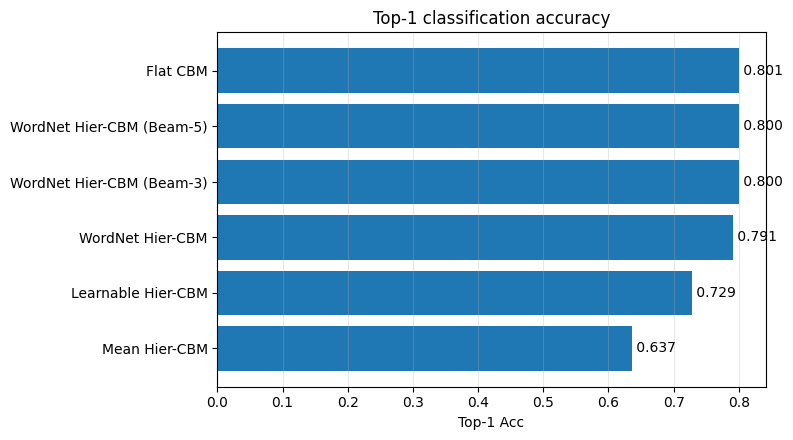

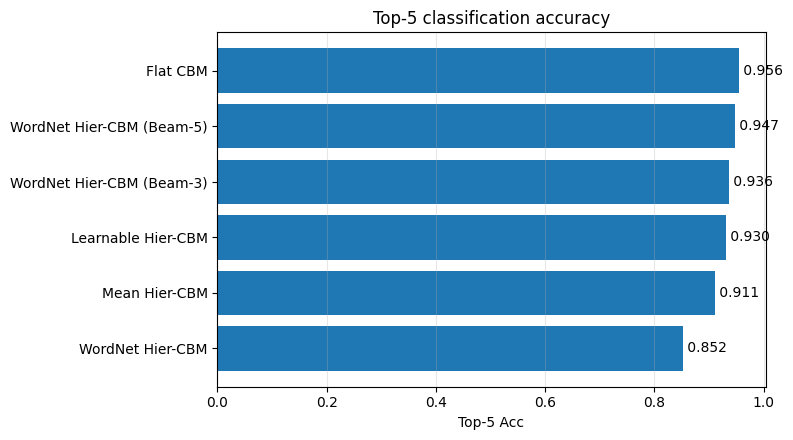

In [14]:
def plot_metric_bar(df, metric, title=None, filename=None):
    plot_df = df.sort_values(metric, ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(plot_df['Model'], plot_df[metric])
    ax.set_xlabel(metric)
    ax.set_title(title or metric)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(plot_df[metric]):
        ax.text(v, i, f' {v:.3f}', va='center')
    plt.tight_layout()
    if filename:
        plt.savefig(os.path.join(EVAL_DIR, filename), dpi=180, bbox_inches='tight')
    plt.show()

if len(perf_df) > 0:
    plot_metric_bar(perf_df, 'Top-1 Acc', 'Top-1 classification accuracy', 'top1_accuracy.png')
    plot_metric_bar(perf_df, 'Top-5 Acc', 'Top-5 classification accuracy', 'top5_accuracy.png')

## 9. Concept quality metrics

Mean concept accuracy is useful but can hide rare-concept failures. For this reason, we also compute macro-F1 and balanced accuracy across concepts.

In [15]:
def binary_metric_report(y_true, y_prob, threshold=0.5, true_threshold=0.5, names=None):
    """Robust multi-label binary metrics.

    Returns both aggregate scores and a per-concept table. Metrics that are genuinely undefined
    are kept as NaN in the detail table but ignored in aggregate means.
    """
    if y_prob is None:
        return None
    y_true = (np.asarray(y_true) >= true_threshold).astype(int)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    y_prob = np.asarray(y_prob)

    if y_true.ndim != 2 or y_pred.ndim != 2:
        raise ValueError(f'Expected 2D arrays, got y_true={y_true.shape}, y_pred={y_pred.shape}')

    n_concepts = y_true.shape[1]
    if names is None:
        names = [str(i) for i in range(n_concepts)]

    rows = []
    per_acc, per_f1, per_bal = [], [], []
    for j in range(n_concepts):
        yt = y_true[:, j]
        yp = y_pred[:, j]
        support_pos = int(yt.sum())
        support_neg = int((1 - yt).sum())
        pred_pos = int(yp.sum())
        prevalence = support_pos / max(len(yt), 1)
        pred_rate = pred_pos / max(len(yp), 1)
        acc = float((yt == yp).mean())
        f1 = float(f1_score(yt, yp, zero_division=0))

        if support_pos == 0 or support_neg == 0:
            bal = np.nan
            bal_defined = False
        else:
            bal = float(balanced_accuracy_score(yt, yp))
            bal_defined = True

        per_acc.append(acc)
        per_f1.append(f1)
        per_bal.append(bal)
        rows.append({
            'concept_idx': j,
            'concept': names[j],
            'accuracy': acc,
            'f1': f1,
            'balanced_accuracy': bal,
            'balanced_accuracy_defined': bal_defined,
            'support_pos': support_pos,
            'support_neg': support_neg,
            'prevalence': prevalence,
            'pred_pos': pred_pos,
            'pred_rate': pred_rate,
            'mean_prob': float(np.nanmean(y_prob[:, j])),
        })

    per_table = pd.DataFrame(rows)
    return {
        'mean_accuracy': float(np.nanmean(per_acc)),
        'macro_f1': float(np.nanmean(per_f1)),
        'balanced_accuracy': float(np.nanmean(per_bal)) if np.isfinite(per_bal).any() else np.nan,
        'n_outputs': int(n_concepts),
        'n_balanced_undefined': int((~per_table['balanced_accuracy_defined']).sum()),
        'per_accuracy': np.array(per_acc),
        'per_f1': np.array(per_f1),
        'per_balanced_accuracy': np.array(per_bal),
        'per_table': per_table,
    }


def safe_binary_metrics(y_true, y_prob, threshold=0.5, true_threshold=0.5, names=None):
    return binary_metric_report(y_true, y_prob, threshold, true_threshold, names=names)


def safe_regression_metrics(y_true, y_prob, names=None):
    if y_prob is None:
        return None
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    mae = np.abs(y_true - y_prob).mean(axis=0)
    mse = ((y_true - y_prob) ** 2).mean(axis=0)
    if names is None:
        names = [str(i) for i in range(y_true.shape[1])]
    per_table = pd.DataFrame({
        'concept_idx': np.arange(y_true.shape[1]),
        'concept': names,
        'mae': mae,
        'mse': mse,
        'target_mean': y_true.mean(axis=0),
        'pred_mean': y_prob.mean(axis=0),
    })
    return {'mean_mae': float(mae.mean()), 'mean_mse': float(mse.mean()), 'per_mae': mae, 'per_mse': mse, 'per_table': per_table}

fine_names = attrs_ordered['attr_name'].tolist() if 'attrs_ordered' in globals() else attrs_df.sort_values('attr_id')['attr_name'].tolist()
part_names = hier_parts
region_names = hier_regions

concept_rows = []
concept_details = {}
for name, res in results.items():
    # WordNet Beam variants are duplicate inference views of the same WordNet model and do not expose global CUB concepts.
    fine = safe_binary_metrics(res['fine_true'], res.get('fine_pred'), FINE_THRESHOLD, names=fine_names)

    # Parent STRENGTH metrics: these align with how Mean/Hier CBMs are trained (continuous evidence strengths).
    part_strength_bin = safe_binary_metrics(
        res['part_strength_true'], res.get('part_pred'), PART_THRESHOLD,
        true_threshold=PARENT_STRENGTH_THRESHOLD, names=part_names
    )
    region_strength_bin = safe_binary_metrics(
        res['region_strength_true'], res.get('region_pred'), REGION_THRESHOLD,
        true_threshold=PARENT_STRENGTH_THRESHOLD, names=region_names
    )
    part_reg = safe_regression_metrics(res['part_strength_true'], res.get('part_pred'), names=part_names)
    region_reg = safe_regression_metrics(res['region_strength_true'], res.get('region_pred'), names=region_names)

    # Parent PRESENCE metrics are diagnostic only. Presence means "any child concept is active", which is often
    # positive for most anatomical groups and is not the target used by mean-pooling training losses.
    part_presence_bin = safe_binary_metrics(res['part_true'], res.get('part_pred'), PART_THRESHOLD, names=part_names)
    region_presence_bin = safe_binary_metrics(res['region_true'], res.get('region_pred'), REGION_THRESHOLD, names=region_names)

    concept_details[name] = {
        'fine': fine,
        'part_strength_bin': part_strength_bin,
        'region_strength_bin': region_strength_bin,
        'part_reg': part_reg,
        'region_reg': region_reg,
        'part_presence_bin_diagnostic': part_presence_bin,
        'region_presence_bin_diagnostic': region_presence_bin,
    }
    concept_rows.append({
        'Model': name,
        'Fine Acc': np.nan if fine is None else fine['mean_accuracy'],
        'Fine Macro-F1': np.nan if fine is None else fine['macro_f1'],
        'Fine Balanced Acc': np.nan if fine is None else fine['balanced_accuracy'],
        'Fine BalAcc undefined #': np.nan if fine is None else fine['n_balanced_undefined'],
        'Part Strength Acc': np.nan if part_strength_bin is None else part_strength_bin['mean_accuracy'],
        'Part Strength F1': np.nan if part_strength_bin is None else part_strength_bin['macro_f1'],
        'Part Strength MAE': np.nan if part_reg is None else part_reg['mean_mae'],
        'Region Strength Acc': np.nan if region_strength_bin is None else region_strength_bin['mean_accuracy'],
        'Region Strength F1': np.nan if region_strength_bin is None else region_strength_bin['macro_f1'],
        'Region Strength MAE': np.nan if region_reg is None else region_reg['mean_mae'],
        'Part Presence Acc Diagnostic': np.nan if part_presence_bin is None else part_presence_bin['mean_accuracy'],
        'Region Presence Acc Diagnostic': np.nan if region_presence_bin is None else region_presence_bin['mean_accuracy'],
    })

concept_df = pd.DataFrame(concept_rows)
format_cols = {c: '{:.4f}' for c in concept_df.columns if c != 'Model' and not c.endswith('#')}
format_cols.update({c: '{:.0f}' for c in concept_df.columns if c.endswith('#')})
display(concept_df.style.format(format_cols, na_rep='N/A'))
concept_df.to_csv(os.path.join(EVAL_DIR, 'concept_quality.csv'), index=False)

# Explicit NaN/N/A diagnostics so missing metrics are not mistaken for crashes.
nan_rows = []
for name, details in concept_details.items():
    for block, rep in details.items():
        if rep is None:
            reason = 'not applicable: this model/inference view does not expose this global concept level'
            nan_rows.append({'Model': name, 'Metric block': block, 'Status': 'N/A', 'Reason': reason})
        elif 'n_balanced_undefined' in rep and rep['n_balanced_undefined'] > 0:
            reason = f"balanced accuracy undefined for {rep['n_balanced_undefined']} outputs with only one GT class in the test split"
            nan_rows.append({'Model': name, 'Metric block': block, 'Status': 'partially undefined', 'Reason': reason})
metric_nan_diagnostics = pd.DataFrame(nan_rows)
metric_nan_diagnostics.to_csv(os.path.join(EVAL_DIR, 'metric_nan_diagnostics.csv'), index=False)
if len(metric_nan_diagnostics) > 0:
    print('Metric N/A / NaN diagnostics:')
    display(metric_nan_diagnostics)

print('Interpretation note: for Mean/Hier CBMs, part/region outputs are evidence-strength scores. Strength Acc/MAE are primary; Presence Acc is diagnostic only.')


,Model,Fine Acc,Fine Macro-F1,Fine Balanced Acc,Fine BalAcc undefined #,Part Strength Acc,Part Strength F1,Part Strength MAE,Region Strength Acc,Region Strength F1,Region Strength MAE,Part Presence Acc Diagnostic,Region Presence Acc Diagnostic
0,Flat CBM,0.8133,0.2042,0.5938,0,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,Mean Hier-CBM,0.6832,0.1404,0.5195,0,0.6786,0.0001,0.2749,0.8813,0.0000,0.2237,0.3731,0.1546
2,Learnable Hier-CBM,0.8818,0.2351,0.6040,0,1.0000,0.0000,0.3768,1.0000,0.0000,0.2479,0.1256,0.0451
3,WordNet Hier-CBM,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
4,WordNet Hier-CBM (Beam-3),N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
5,WordNet Hier-CBM (Beam-5),N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


Metric N/A / NaN diagnostics:


,Model,Metric block,Status,Reason
0,Flat CBM,part_strength_bin,N/A,not applicable: this model/inference view does...
1,Flat CBM,region_strength_bin,N/A,not applicable: this model/inference view does...
2,Flat CBM,part_reg,N/A,not applicable: this model/inference view does...
3,Flat CBM,region_reg,N/A,not applicable: this model/inference view does...
4,Flat CBM,part_presence_bin_diagnostic,N/A,not applicable: this model/inference view does...
5,Flat CBM,region_presence_bin_diagnostic,N/A,not applicable: this model/inference view does...
6,Mean Hier-CBM,part_strength_bin,partially undefined,balanced accuracy undefined for 17 outputs wit...
7,Mean Hier-CBM,region_strength_bin,partially undefined,balanced accuracy undefined for 4 outputs with...
8,Learnable Hier-CBM,part_strength_bin,partially undefined,balanced accuracy undefined for 17 outputs wit...
9,Learnable Hier-CBM,region_strength_bin,partially undefined,balanced accuracy undefined for 4 outputs with...


Interpretation note: for Mean/Hier CBMs, part/region outputs are evidence-strength scores. Strength Acc/MAE are primary; Presence Acc is diagnostic only.


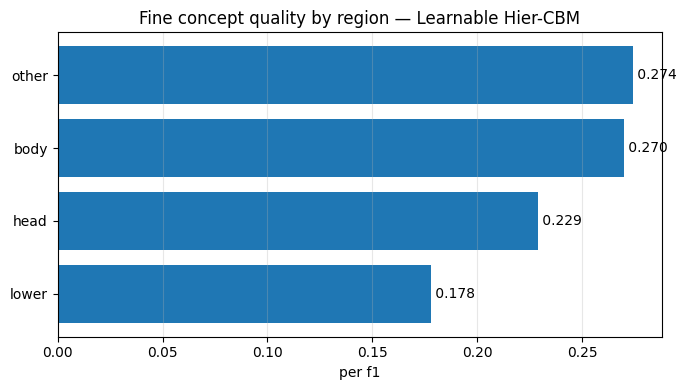

In [16]:
def plot_concept_quality_by_region(model_name, metric='per_f1'):
    details = concept_details.get(model_name, {}).get('fine')
    if details is None:
        print(f'No fine concepts for {model_name}')
        return
    values = details[metric]
    df = hierarchy_df.copy()
    df['value'] = values[df['attr_id'].values - 1]
    grouped = df.groupby('region')['value'].mean().sort_values()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(grouped.index, grouped.values)
    ax.set_xlabel(metric.replace('_', ' '))
    ax.set_title(f'Fine concept quality by region — {model_name}')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(grouped.values):
        ax.text(v, i, f' {v:.3f}', va='center')
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_DIR, f'{model_name.replace(" ", "_")}_concept_quality_by_region.png'), dpi=180, bbox_inches='tight')
    plt.show()

if len(results) > 0:
    main_model_name = 'Learnable Hier-CBM' if 'Learnable Hier-CBM' in results else list(results.keys())[0]
    plot_concept_quality_by_region(main_model_name, metric='per_f1')

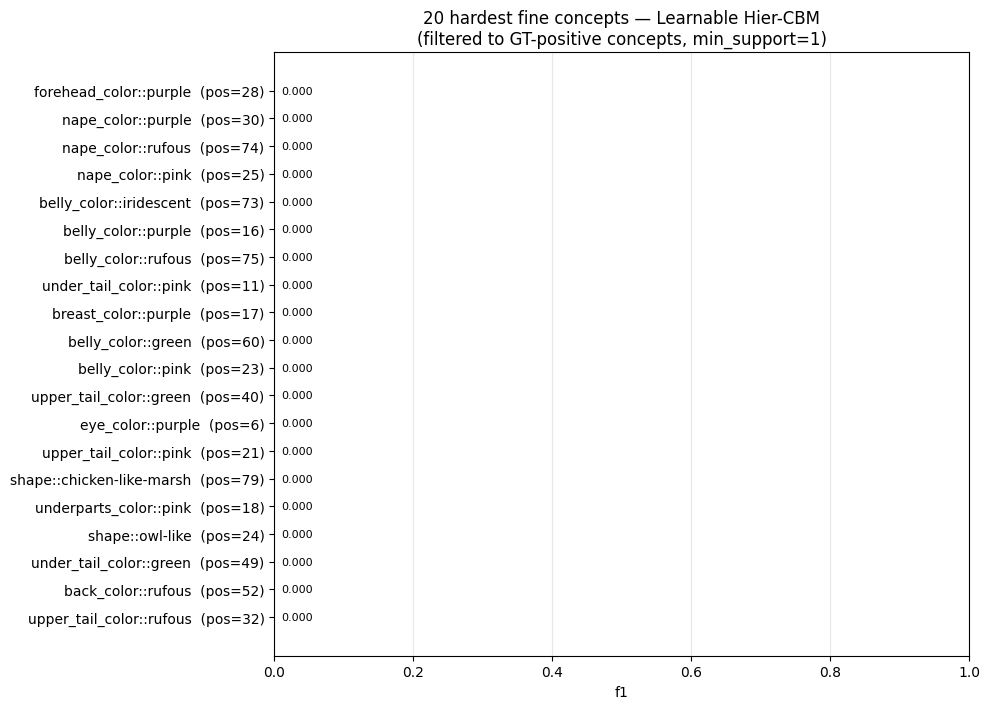

,concept_idx,short_name,part,region,f1,support_pos,prevalence,pred_rate,mean_prob
155,155,forehead_color::purple,forehead,head,0.0000,28,0.0048,0.0000,0.0093
185,185,nape_color::purple,nape,head,0.0000,30,0.0052,0.0000,0.0102
186,186,nape_color::rufous,nape,head,0.0000,74,0.0128,0.0000,0.0234
191,191,nape_color::pink,nape,head,0.0000,25,0.0043,0.0010,0.0168
199,199,belly_color::iridescent,belly,body,0.0000,73,0.0126,0.0000,0.0305
200,200,belly_color::purple,belly,body,0.0000,16,0.0028,0.0000,0.0044
201,201,belly_color::rufous,belly,body,0.0000,75,0.0129,0.0000,0.0145
176,176,under_tail_color::pink,tail,lower,0.0000,11,0.0019,0.0000,0.0045
108,108,breast_color::purple,breast,body,0.0000,17,0.0029,0.0000,0.0044
205,205,belly_color::green,belly,body,0.0000,60,0.0104,0.0002,0.0208


In [17]:

def concept_detail_table(model_name):
    details = concept_details.get(model_name, {}).get('fine')
    if details is None:
        return pd.DataFrame()
    table = details.get('per_table')
    if table is None:
        values = details['per_f1']
        table = pd.DataFrame({'concept_idx': np.arange(len(values)), 'f1': values})
    df = table.copy()
    meta = hierarchy_df.copy()
    meta['concept_idx'] = meta['attr_id'].astype(int) - 1
    keep = ['concept_idx', 'attr_name', 'part', 'region']
    df = df.merge(meta[keep], on='concept_idx', how='left')
    if 'concept' not in df.columns or df['concept'].isna().all():
        df['concept'] = df['attr_name']
    df['short_name'] = df['concept'].astype(str).str.replace('has_', '', regex=False)
    return df


def plot_hardest_concepts(model_name, metric='f1', n=20, min_support=1):
    df = concept_detail_table(model_name)
    if df.empty:
        print(f'No fine concepts for {model_name}')
        return
    if metric not in df.columns:
        # Backwards compatibility with previous names.
        aliases = {'per_f1': 'f1', 'per_accuracy': 'accuracy', 'per_balanced_accuracy': 'balanced_accuracy'}
        metric = aliases.get(metric, metric)
    if metric not in df.columns:
        raise ValueError(f'Unknown metric {metric}. Available: {list(df.columns)}')

    plot_df = df.copy()
    if 'support_pos' in plot_df.columns:
        plot_df = plot_df[plot_df['support_pos'] >= min_support]
    plot_df = plot_df[np.isfinite(plot_df[metric])]
    if len(plot_df) == 0:
        print(f'No finite {metric} values to plot for {model_name}.')
        return

    worst = plot_df.sort_values(metric, ascending=True).head(n).iloc[::-1]
    labels = [f"{r.short_name}  (pos={int(r.support_pos)})" if 'support_pos' in worst.columns else r.short_name
              for _, r in worst.iterrows()]

    fig, ax = plt.subplots(figsize=(10, max(5, n * 0.36)))
    bars = ax.barh(labels, worst[metric].values)
    ax.set_xlim(0, 1 if metric in ['f1', 'accuracy', 'balanced_accuracy'] else max(1e-6, float(worst[metric].max()) * 1.1))
    ax.set_xlabel(metric.replace('_', ' '))
    ax.set_title(f'{min(n, len(worst))} hardest fine concepts — {model_name}\n(filtered to GT-positive concepts, min_support={min_support})')
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, worst[metric].values):
        ax.text(min(val + 0.01, ax.get_xlim()[1]), bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    path = os.path.join(EVAL_DIR, f'{model_name.replace(" ", "_")}_hardest_concepts_{metric}.png')
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()

    # Also display and save the actual table so the plot is not the only source of evidence.
    cols = [c for c in ['concept_idx', 'short_name', 'part', 'region', metric, 'support_pos', 'prevalence', 'pred_rate', 'mean_prob'] if c in worst.columns]
    table_path = os.path.join(EVAL_DIR, f'{model_name.replace(" ", "_")}_hardest_concepts_{metric}.csv')
    worst.iloc[::-1][cols].to_csv(table_path, index=False)
    display(worst.iloc[::-1][cols].style.format({metric: '{:.4f}', 'prevalence': '{:.4f}', 'pred_rate': '{:.4f}', 'mean_prob': '{:.4f}'}, na_rep='N/A'))

if len(results) > 0:
    plot_hardest_concepts(main_model_name, metric='f1', n=20, min_support=1)


## 10. Hierarchy consistency metrics

These metrics measure whether predictions respect the declared parent-child structure.

Two complementary quantities are computed:

- **Binary violation rate**: child active while parent inactive.
- **Soft violation magnitude**: average value of `max(0, child_score - parent_score)`.

In [18]:
def fine_to_part_parent_scores(fine_scores, part_scores, M_fine):
    # For each fine concept, retrieve its parent part score.
    attr_to_part = M_fine.argmax(dim=0).cpu().numpy()
    return part_scores[:, attr_to_part]

def part_to_region_parent_scores(part_scores, region_scores, part_to_region):
    return region_scores[:, part_to_region.cpu().numpy()]

def hierarchy_consistency_metrics(res):
    fine_pred = res.get('fine_pred')
    part_pred = res.get('part_pred')
    region_pred = res.get('region_pred')
    if fine_pred is None or part_pred is None or region_pred is None:
        return None

    parent_part = fine_to_part_parent_scores(fine_pred, part_pred, hier_M_fine)
    parent_region = part_to_region_parent_scores(part_pred, region_pred, hier_part_to_region)

    fine_bin = fine_pred >= FINE_THRESHOLD
    part_parent_bin = parent_part >= PART_THRESHOLD
    part_bin = part_pred >= PART_THRESHOLD
    region_parent_bin = parent_region >= REGION_THRESHOLD

    fine_part_binary_viol = np.mean(fine_bin & (~part_parent_bin))
    part_region_binary_viol = np.mean(part_bin & (~region_parent_bin))
    fine_part_soft = np.maximum(0.0, fine_pred - parent_part).mean()
    part_region_soft = np.maximum(0.0, part_pred - parent_region).mean()

    return {
        'Fine→Part Binary Violation': float(fine_part_binary_viol),
        'Part→Region Binary Violation': float(part_region_binary_viol),
        'Fine→Part Soft Violation': float(fine_part_soft),
        'Part→Region Soft Violation': float(part_region_soft),
        'Overall Binary Violation': float((fine_part_binary_viol + part_region_binary_viol) / 2),
        'Overall Soft Violation': float((fine_part_soft + part_region_soft) / 2),
        'Mean Part Score': float(np.mean(part_pred)),
        'Mean Region Score': float(np.mean(region_pred)),
        'Part Active Rate@thr': float(np.mean(part_bin)),
        'Region Active Rate@thr': float(np.mean(region_pred >= REGION_THRESHOLD)),
    }

consistency_rows = []
for name, res in results.items():
    m = hierarchy_consistency_metrics(res)
    if m is not None:
        consistency_rows.append({'Model': name, **m})

consistency_df = pd.DataFrame(consistency_rows)
if len(consistency_df) > 0:
    display(consistency_df.style.format({c: '{:.4f}' for c in consistency_df.columns if c != 'Model'}))
    consistency_df.to_csv(os.path.join(EVAL_DIR, 'hierarchy_consistency.csv'), index=False)
    print('Diagnostic note: if Mean Part/Region Score and Active Rate are close to 1.0, hierarchy violation rates may be artificially low.')
else:
    print('No hierarchical model outputs available for consistency evaluation.')


,Model,Fine→Part Binary Violation,Part→Region Binary Violation,Fine→Part Soft Violation,Part→Region Soft Violation,Overall Binary Violation,Overall Soft Violation,Mean Part Score,Mean Region Score,Part Active Rate@thr,Region Active Rate@thr
0,Mean Hier-CBM,0.0215,0.2498,0.0254,0.1230,0.1357,0.0742,0.3082,0.3089,0.3214,0.1187
1,Learnable Hier-CBM,0.1109,0.0000,0.0262,0.1190,0.0555,0.0726,0.4720,0.3443,0.0000,0.0000


Diagnostic note: if Mean Part/Region Score and Active Rate are close to 1.0, hierarchy violation rates may be artificially low.


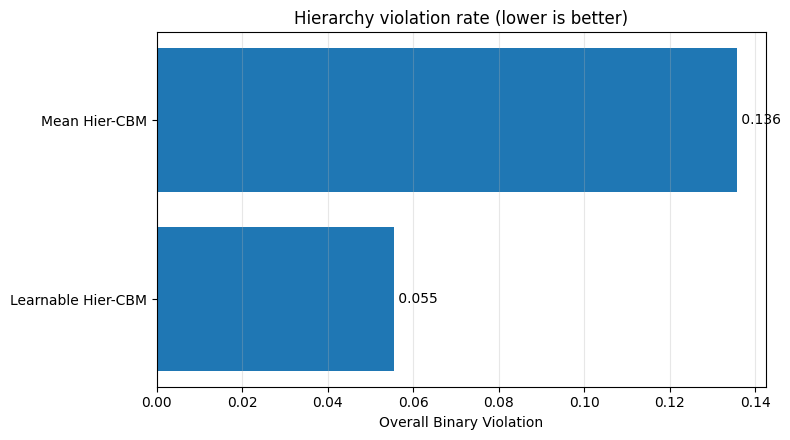

In [19]:
if len(consistency_df) > 0:
    plot_metric_bar(consistency_df, 'Overall Binary Violation', 'Hierarchy violation rate (lower is better)', 'hierarchy_violation_rate.png')

## 11. Semantic mistake severity

Standard accuracy treats all wrong predictions as equally wrong. Here, mistakes are grouped by semantic proximity.

The fallback taxonomy groups classes by tokens in the class names. If you have a better WordNet or biological taxonomy mapping, replace `class_taxonomy` above and re-run this section.

In [20]:
def mistake_category(y_true, y_pred, taxonomy):
    if y_true == y_pred:
        return 'correct'
    t = taxonomy[int(y_true)]
    p = taxonomy[int(y_pred)]
    if t['genus'] == p['genus']:
        return 'same_genus'
    if t['family'] == p['family']:
        return 'same_family'
    return 'different_family'

def severity_score(category):
    return {
        'correct': 0,
        'same_genus': 1,
        'same_family': 2,
        'different_family': 3,
    }[category]

def semantic_mistake_metrics(res, taxonomy):
    y_true = res['y_true']
    y_pred = res['y_pred']
    cats = [mistake_category(t, p, taxonomy) for t, p in zip(y_true, y_pred)]
    wrong_cats = [c for c in cats if c != 'correct']
    counts = Counter(cats)
    wrong_counts = Counter(wrong_cats)
    severity = np.array([severity_score(c) for c in cats], dtype=float)
    wrong_severity = np.array([severity_score(c) for c in wrong_cats], dtype=float)
    n = len(cats)
    n_wrong = n - counts['correct']
    return {
        'Taxonomy Source': TAXONOMY_SOURCE,
        'Error Rate': n_wrong / n,
        'Mean Severity All': float(severity.mean()),
        'Median Severity All': float(np.median(severity)),
        'Mean Severity Wrong Only': float(wrong_severity.mean()) if n_wrong > 0 else 0.0,
        'Median Severity Wrong Only': float(np.median(wrong_severity)) if n_wrong > 0 else 0.0,
        'Same-Genus Error %': wrong_counts['same_genus'] / n_wrong if n_wrong > 0 else 0.0,
        'Same-Family Error %': wrong_counts['same_family'] / n_wrong if n_wrong > 0 else 0.0,
        'Different-Family Error %': wrong_counts['different_family'] / n_wrong if n_wrong > 0 else 0.0,
        'categories': cats,
    }

mistake_rows = []
mistake_details = {}
for name, res in results.items():
    m = semantic_mistake_metrics(res, class_taxonomy)
    mistake_details[name] = m
    row = {'Model': name}
    row.update({k: v for k, v in m.items() if k != 'categories'})
    mistake_rows.append(row)

mistake_df = pd.DataFrame(mistake_rows).sort_values('Mean Severity Wrong Only')
display(mistake_df.style.format({c: '{:.4f}' for c in mistake_df.columns if c not in ['Model', 'Taxonomy Source']}))
mistake_df.to_csv(os.path.join(EVAL_DIR, 'semantic_mistake_severity.csv'), index=False)

if TAXONOMY_SOURCE == 'weak name-token fallback':
    print('Warning: semantic mistake severity is based on a weak fallback, not true biological taxonomy.')


,Model,Taxonomy Source,Error Rate,Mean Severity All,Median Severity All,Mean Severity Wrong Only,Median Severity Wrong Only,Same-Genus Error %,Same-Family Error %,Different-Family Error %
0,Flat CBM,WordNet family-like/genus-like + fallback,0.1990,0.4422,0.0000,2.2220,3.0000,0.3270,0.1240,0.5490
5,WordNet Hier-CBM (Beam-5),WordNet family-like/genus-like + fallback,0.1995,0.4489,0.0000,2.2500,3.0000,0.3131,0.1237,0.5631
4,WordNet Hier-CBM (Beam-3),WordNet family-like/genus-like + fallback,0.1999,0.4499,0.0000,2.2513,3.0000,0.3126,0.1235,0.5639
3,WordNet Hier-CBM,WordNet family-like/genus-like + fallback,0.2087,0.4700,0.0000,2.2523,3.0000,0.3110,0.1257,0.5633
2,Learnable Hier-CBM,WordNet family-like/genus-like + fallback,0.2711,0.6200,0.0000,2.2864,3.0000,0.2966,0.1203,0.5831
1,Mean Hier-CBM,WordNet family-like/genus-like + fallback,0.3633,0.8315,0.0000,2.2888,3.0000,0.2983,0.1145,0.5872


## 11.1 WordNet-specific diagnostics: beam search, oracle routing, and local concept quality

The WordNet model is a hierarchical classifier with local concept bottleneck heads. Therefore it needs diagnostics that do not apply to the global visual CBMs:

- **beam search**: tests whether strict greedy routing loses examples because the correct branch was ranked second or third;
- **oracle routing**: uses true family-like/genus-like labels to diagnose where error propagation happens; this is not deployable inference;
- **local concept quality**: evaluates whether local root/family/genus concept heads align with CUB attributes.


In [21]:
def _binary_metrics_from_counts(tp, fp, tn, fn):
    acc = (tp + tn) / max(tp + fp + tn + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-12)
    tpr = rec
    tnr = tn / max(tn + fp, 1)
    bal = 0.5 * (tpr + tnr)
    return acc, f1, bal, prec, rec

@torch.no_grad()
def evaluate_wordnet_oracle_routing(model, loader):
    if not isinstance(model, WordNetCBM):
        return pd.DataFrame()
    model.eval()
    total = 0
    greedy_sp_correct = 0
    true_family_genus_correct = 0
    true_family_pred_genus_species_correct = 0
    true_family_true_genus_species_correct = 0

    for images, labels, fine_gt, img_ids, filepaths in tqdm(loader, desc='WordNet oracle routing'):
        images = images.to(device)
        labels = labels.to(device)
        true_genus_np, true_family_np = taxonomy_targets_from_labels(labels)
        true_genus = torch.tensor(true_genus_np, dtype=torch.long, device=device)
        true_family = torch.tensor(true_family_np, dtype=torch.long, device=device)
        B = labels.size(0)
        total += B

        # Greedy baseline.
        _, _, greedy_species_logits = model.forward_greedy_logits(images)
        greedy_sp_correct += (greedy_species_logits.argmax(dim=1) == labels).sum().item()

        # True family + true genus: teacher-forced branch to species.
        fam_logits, genus_logits_tf, species_logits_tf, *_ = model.forward_train(images, true_family, true_genus)
        pred_genus_tf = genus_logits_tf.argmax(dim=1)
        true_family_genus_correct += (pred_genus_tf == true_genus).sum().item()
        true_family_true_genus_species_correct += (species_logits_tf.argmax(dim=1) == labels).sum().item()

        # True family only: predict genus within true family, then route species through predicted genus.
        feats = model.features(images)
        species_logits_oracle_family = torch.full((B, N_CLASSES), -1e4, device=device)
        for gid in pred_genus_tf.unique().tolist():
            gid = int(gid)
            m = pred_genus_tf == gid
            if str(gid) not in model.genus_heads:
                continue
            s_log, _ = model.genus_heads[str(gid)](feats[m])
            for li, sid in enumerate(genus_to_species_map[gid]):
                species_logits_oracle_family[m, sid] = s_log[:, li]
        true_family_pred_genus_species_correct += (species_logits_oracle_family.argmax(dim=1) == labels).sum().item()

    rows = [{
        'Diagnostic': 'Greedy species accuracy',
        'Accuracy': greedy_sp_correct / total,
        'Interpretation': 'Deployable strict hierarchical inference',
    }, {
        'Diagnostic': 'True family-like -> predicted genus-like accuracy',
        'Accuracy': true_family_genus_correct / total,
        'Interpretation': 'How good genus routing is if the family-like branch is correct',
    }, {
        'Diagnostic': 'True family-like -> predicted genus-like -> species accuracy',
        'Accuracy': true_family_pred_genus_species_correct / total,
        'Interpretation': 'Species accuracy if only the first routing step is fixed',
    }, {
        'Diagnostic': 'True family-like + true genus-like -> species accuracy',
        'Accuracy': true_family_true_genus_species_correct / total,
        'Interpretation': 'Upper-bound local species-head quality under correct branch',
    }]
    return pd.DataFrame(rows)

@torch.no_grad()
def evaluate_wordnet_local_concept_quality(model, loader, threshold=0.5):
    if not isinstance(model, WordNetCBM):
        return pd.DataFrame()
    model.eval()
    stats = defaultdict(lambda: {'tp':0, 'fp':0, 'tn':0, 'fn':0, 'n_entries':0})
    def add_stats(level, pred, gt):
        pred = pred.detach().cpu().int()
        gt = gt.detach().cpu().int()
        stats[level]['tp'] += int(((pred == 1) & (gt == 1)).sum().item())
        stats[level]['fp'] += int(((pred == 1) & (gt == 0)).sum().item())
        stats[level]['tn'] += int(((pred == 0) & (gt == 0)).sum().item())
        stats[level]['fn'] += int(((pred == 0) & (gt == 1)).sum().item())
        stats[level]['n_entries'] += int(gt.numel())

    for images, labels, fine_gt, img_ids, filepaths in tqdm(loader, desc='WordNet local concept quality'):
        images = images.to(device)
        fine_gt = fine_gt.to(device)
        genus_np, family_np = taxonomy_targets_from_labels(labels)
        true_genus = torch.tensor(genus_np, dtype=torch.long, device=device)
        true_family = torch.tensor(family_np, dtype=torch.long, device=device)
        _, _, _, root_c, fam_cp, gen_cp = model.forward_train(images, true_family, true_genus)
        add_stats('root local concepts', (root_c >= threshold).float(), fine_gt[:, root_concept_mask])
        for fid, (m, fam_c) in fam_cp.items():
            add_stats('family-local concepts', (fam_c >= threshold).float(), fine_gt[m][:, family_concept_masks[fid]])
        for gid, (m, gen_c) in gen_cp.items():
            add_stats('genus-local concepts', (gen_c >= threshold).float(), fine_gt[m][:, genus_concept_masks[gid]])

    rows = []
    for level, s in stats.items():
        acc, f1, bal, prec, rec = _binary_metrics_from_counts(s['tp'], s['fp'], s['tn'], s['fn'])
        rows.append({
            'Level': level,
            'Accuracy': acc,
            'F1-like': f1,
            'Balanced Accuracy': bal,
            'Precision': prec,
            'Recall': rec,
            'Entries': s['n_entries'],
        })
    return pd.DataFrame(rows)

wordnet_diagnostics = {}
wordnet_base_model = models_to_eval.get('WordNet Hier-CBM')
if wordnet_base_model is not None:
    if RUN_WORDNET_ORACLE_ROUTING:
        oracle_routing_df = evaluate_wordnet_oracle_routing(wordnet_base_model, test_loader)
        oracle_routing_df.to_csv(EVAL_DIR / 'wordnet_oracle_routing_diagnostics.csv', index=False)
        print('WordNet oracle-routing diagnostics:')
        display(oracle_routing_df.style.format({'Accuracy': '{:.4f}'}))
        wordnet_diagnostics['oracle_routing'] = oracle_routing_df
    if RUN_WORDNET_LOCAL_CONCEPT_QUALITY:
        local_concept_quality_df = evaluate_wordnet_local_concept_quality(wordnet_base_model, test_loader)
        local_concept_quality_df.to_csv(EVAL_DIR / 'wordnet_local_concept_quality.csv', index=False)
        print('WordNet local concept-head quality:')
        display(local_concept_quality_df.style.format({c: '{:.4f}' for c in local_concept_quality_df.columns if c != 'Level' and c != 'Entries'}))
        wordnet_diagnostics['local_concept_quality'] = local_concept_quality_df
else:
    oracle_routing_df = pd.DataFrame()
    local_concept_quality_df = pd.DataFrame()
    print('WordNet-specific diagnostics skipped because WordNet Hier-CBM was not loaded.')


WordNet oracle routing:   0%|          | 0/91 [00:00<?, ?it/s]

WordNet oracle-routing diagnostics:


,Diagnostic,Accuracy,Interpretation
0,Greedy species accuracy,0.7913,Deployable strict hierarchical inference
1,True family-like -> predicted genus-like accuracy,0.9625,How good genus routing is if the family-like branch is correct
2,True family-like -> predicted genus-like -> species accuracy,0.8864,Species accuracy if only the first routing step is fixed
3,True family-like + true genus-like -> species accuracy,0.9184,Upper-bound local species-head quality under correct branch


WordNet local concept quality:   0%|          | 0/91 [00:00<?, ?it/s]

WordNet local concept-head quality:


,Level,Accuracy,F1-like,Balanced Accuracy,Precision,Recall,Entries
0,root local concepts,0.6469,0.4308,0.6207,0.3457,0.5715,463520
1,family-local concepts,0.6890,0.4181,0.6274,0.3499,0.5194,289700
2,genus-local concepts,0.7072,0.4581,0.6435,0.4077,0.5227,173820


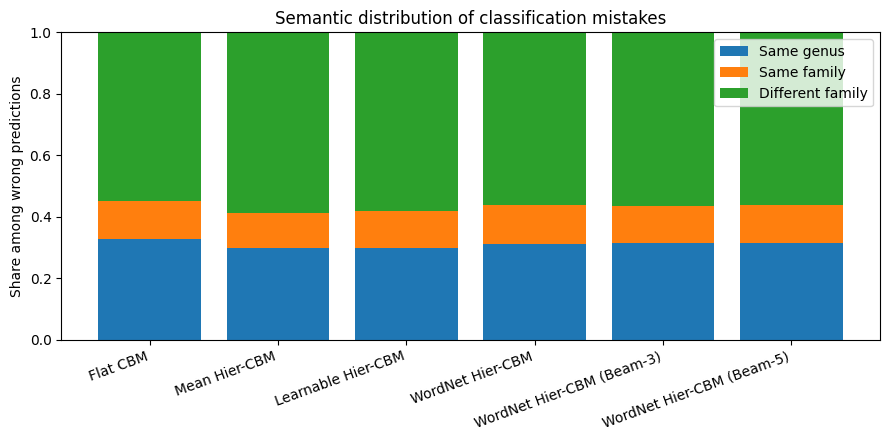

In [22]:
def plot_mistake_distribution(mistake_details, filename='mistake_distribution.png'):
    labels = ['same_genus', 'same_family', 'different_family']
    model_names = list(mistake_details.keys())
    data = []
    for name in model_names:
        cats = [c for c in mistake_details[name]['categories'] if c != 'correct']
        n = max(len(cats), 1)
        cnt = Counter(cats)
        data.append([cnt[l] / n for l in labels])
    data = np.array(data)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    bottom = np.zeros(len(model_names))
    display_labels = ['Same genus', 'Same family', 'Different family']
    for j, lab in enumerate(labels):
        ax.bar(model_names, data[:, j], bottom=bottom, label=display_labels[j])
        bottom += data[:, j]
    ax.set_ylabel('Share among wrong predictions')
    ax.set_title('Semantic distribution of classification mistakes')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_DIR, filename), dpi=180, bbox_inches='tight')
    plt.show()

if len(mistake_details) > 0:
    plot_mistake_distribution(mistake_details)

## 12. Coarse correctness among fine errors

This evaluates whether a model remains useful at a coarser level when it fails at fine-grained species classification.

In [23]:
def coarse_correctness_among_species_errors(res, taxonomy):
    y_true = res['y_true']
    y_pred = res['y_pred']
    wrong = y_true != y_pred
    if wrong.sum() == 0:
        return {'Species Errors': 0, 'Correct Genus Among Errors': np.nan, 'Correct Family Among Errors': np.nan}
    genus_correct = []
    family_correct = []
    for t, p in zip(y_true[wrong], y_pred[wrong]):
        genus_correct.append(taxonomy[int(t)]['genus'] == taxonomy[int(p)]['genus'])
        family_correct.append(taxonomy[int(t)]['family'] == taxonomy[int(p)]['family'])
    return {
        'Species Errors': int(wrong.sum()),
        'Correct Genus Among Errors': float(np.mean(genus_correct)),
        'Correct Family Among Errors': float(np.mean(family_correct)),
    }

coarse_rows = []
for name, res in results.items():
    coarse_rows.append({'Model': name, **coarse_correctness_among_species_errors(res, class_taxonomy)})

coarse_error_df = pd.DataFrame(coarse_rows)
display(coarse_error_df.style.format({c: '{:.4f}' for c in coarse_error_df.columns if c not in ['Model', 'Species Errors']}))
coarse_error_df.to_csv(os.path.join(EVAL_DIR, 'coarse_correctness_among_errors.csv'), index=False)

,Model,Species Errors,Correct Genus Among Errors,Correct Family Among Errors
0,Flat CBM,1153,0.3270,0.4423
1,Mean Hier-CBM,2105,0.2983,0.4086
2,Learnable Hier-CBM,1571,0.2966,0.4137
3,WordNet Hier-CBM,1209,0.3110,0.4326
4,WordNet Hier-CBM (Beam-3),1158,0.3126,0.4318
5,WordNet Hier-CBM (Beam-5),1156,0.3131,0.4325


## 13. Confusion matrix reordered by semantic grouping

For readability, the full 200×200 matrix is reordered according to the taxonomy. In slides, it is usually better to show this as a qualitative heatmap without all class names.

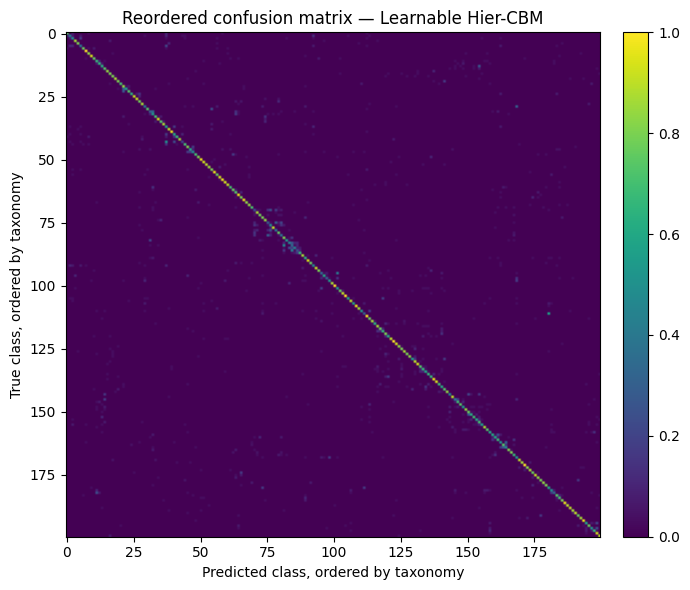

In [24]:
def plot_reordered_confusion(res, taxonomy, normalize=True, filename=None):
    y_true = res['y_true']
    y_pred = res['y_pred']
    order = sorted(range(N_CLASSES), key=lambda c: (taxonomy[c]['family'], taxonomy[c]['genus'], taxonomy[c]['name']))
    order_idx = {c: i for i, c in enumerate(order)}
    cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES))).astype(float)
    cm = cm[np.ix_(order, order)]
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, aspect='auto')
    ax.set_title(f'Reordered confusion matrix — {res["model_name"]}')
    ax.set_xlabel('Predicted class, ordered by taxonomy')
    ax.set_ylabel('True class, ordered by taxonomy')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if filename:
        plt.savefig(os.path.join(EVAL_DIR, filename), dpi=180, bbox_inches='tight')
    plt.show()

if len(results) > 0:
    plot_reordered_confusion(results[main_model_name], class_taxonomy, filename=f'{main_model_name.replace(" ", "_")}_reordered_confusion.png')

## 14. Human-readable multi-level explanations

This section prints compact explanations from region → part → fine concept. It is useful for both correct cases and failure analysis.

In [25]:
def class_label_name(label):
    return classes_df.loc[classes_df['class_id'] == int(label) + 1, 'class_name'].values[0]

def top_items(values, names, k=5):
    idx = np.argsort(values)[::-1][:k]
    return [(names[i], float(values[i])) for i in idx]

def top_present_items(pred_values, true_values, names, k=5, pred_threshold=0.5):
    pred_values = np.asarray(pred_values)
    true_values = np.asarray(true_values)
    candidates = np.where((true_values >= 0.5) & (pred_values >= pred_threshold))[0]
    label = 'present and predicted active'
    if len(candidates) == 0:
        candidates = np.where(true_values >= 0.5)[0]
        label = 'present in GT only'
    if len(candidates) == 0:
        candidates = np.argsort(pred_values)[::-1][:k]
        label = 'top predicted fallback'
    candidates = sorted(candidates, key=lambda j: pred_values[j], reverse=True)[:k]
    return [(names[i], float(pred_values[i])) for i in candidates], label

def explain_result_sample(res, sample_idx, top_k_regions=3, top_k_parts=3, top_k_attrs=5):
    y_true = int(res['y_true'][sample_idx])
    y_pred = int(res['y_pred'][sample_idx])
    fine = res.get('fine_pred')
    part = res.get('part_pred')
    region = res.get('region_pred')
    probs = res['class_probs'][sample_idx]

    print('=' * 90)
    print('Model      :', res['model_name'])
    print('Image      :', res['filepaths'][sample_idx])
    print('True       :', class_label_name(y_true))
    print('Predicted  :', class_label_name(y_pred), f'(p={probs[y_pred]:.3f})')
    print('Correct    :', y_true == y_pred)
    print('Mistake category:', mistake_category(y_true, y_pred, class_taxonomy))

    if fine is None:
        print('\nNo shared 312-concept predictions available for this model.')
        return

    fine_values = fine[sample_idx]
    fine_true = res['fine_true'][sample_idx]
    attr_names = attrs_df['attr_name'].str.replace('has_', '', regex=False).tolist()

    print('\nTop fine concepts that are ground-truth present when possible:')
    items, mode = top_present_items(fine_values, fine_true, attr_names, k=top_k_attrs, pred_threshold=FINE_THRESHOLD)
    print('Selection mode:', mode)
    for name, val in items:
        print(f'  {name:45s} {val:.3f}')

    print('\nTop predicted fine concepts overall:')
    for name, val in top_items(fine_values, attr_names, k=top_k_attrs):
        print(f'  {name:45s} {val:.3f}')

    if part is not None:
        print('\nTop parts:')
        for name, val in top_items(part[sample_idx], hier_parts, k=top_k_parts):
            print(f'  {name:15s} {val:.3f}')

    if region is not None:
        print('\nTop regions:')
        for name, val in top_items(region[sample_idx], hier_regions, k=top_k_regions):
            print(f'  {name:15s} {val:.3f}')

    if part is not None and region is not None:
        print('\nStructured explanation:')
        region_to_parts = defaultdict(list)
        for p, r in REGION_MAP.items():
            if p in hier_part_to_idx and r in hier_region_to_idx:
                region_to_parts[r].append(p)
        top_region_names = [x[0] for x in top_items(region[sample_idx], hier_regions, k=top_k_regions)]
        for region_name in top_region_names:
            r_score = region[sample_idx][hier_region_to_idx[region_name]]
            print(f'  Region {region_name} ({r_score:.3f})')
            candidate_parts = [p for p in region_to_parts[region_name] if p in hier_part_to_idx]
            candidate_parts = sorted(candidate_parts, key=lambda p: part[sample_idx][hier_part_to_idx[p]], reverse=True)
            for part_name in candidate_parts[:top_k_parts]:
                p_idx = hier_part_to_idx[part_name]
                p_score = part[sample_idx][p_idx]
                attr_indices = np.where(hier_M_fine[p_idx].numpy() > 0)[0]
                attr_indices = sorted(attr_indices, key=lambda j: fine_values[j], reverse=True)[:top_k_attrs]
                attrs_str = ', '.join([f'{attr_names[j]}={fine_values[j]:.2f}' for j in attr_indices])
                print(f'    Part {part_name} ({p_score:.3f}): {attrs_str}')


def find_example_indices(res):
    y_true = res['y_true']
    y_pred = res['y_pred']
    cats = np.array([mistake_category(t, p, class_taxonomy) for t, p in zip(y_true, y_pred)])
    examples = {}
    correct = np.where(y_true == y_pred)[0]
    if len(correct):
        examples['correct'] = int(correct[min(42, len(correct) - 1)])
    for cat in ['same_genus', 'same_family', 'different_family']:
        idxs = np.where(cats == cat)[0]
        if len(idxs):
            examples[cat] = int(idxs[0])
    return examples

if len(results) > 0:
    main_model_name = 'Learnable Hier-CBM' if 'Learnable Hier-CBM' in results else list(results.keys())[0]
    res = results[main_model_name]
    example_indices = find_example_indices(res)
    print('Selected examples:', example_indices)
    for key, idx in example_indices.items():
        print('\n### Example:', key)
        explain_result_sample(res, idx)


Selected examples: {'correct': 68, 'same_genus': 3, 'same_family': 231, 'different_family': 2}

### Example: correct
Model      : Learnable Hier-CBM
Image      : 003.Sooty_Albatross/Sooty_Albatross_0005_796342.jpg
True       : 003.Sooty_Albatross
Predicted  : 003.Sooty_Albatross (p=0.871)
Correct    : True
Mistake category: correct

Top fine concepts that are ground-truth present when possible:
Selection mode: present and predicted active
  back_pattern::solid                           0.985
  breast_pattern::solid                         0.983
  bill_shape::hooked_seabird                    0.952
  bill_length::about_the_same_as_head           0.949
  eye_color::black                              0.946

Top predicted fine concepts overall:
  wing_pattern::solid                           0.988
  back_pattern::solid                           0.985
  breast_pattern::solid                         0.983
  head_pattern::plain                           0.977
  tail_pattern::solid            

## 15. Visual grounding with Grad-CAM

These maps are qualitative plausibility checks. They help inspect whether a concept logit is visually grounded in the expected image region, for example whether a bill-related concept focuses near the bill.

They should be interpreted together with quantitative metrics, not as standalone proof of explanation quality.

Fine Grad-CAM selection: GT-present and predicted-active
Part Grad-CAM selection: GT-present fallback
Region Grad-CAM selection: GT-present fallback
Note: CUB concepts are image-level annotations, not part masks. Bad localization is a valid diagnostic, not necessarily a plotting bug.


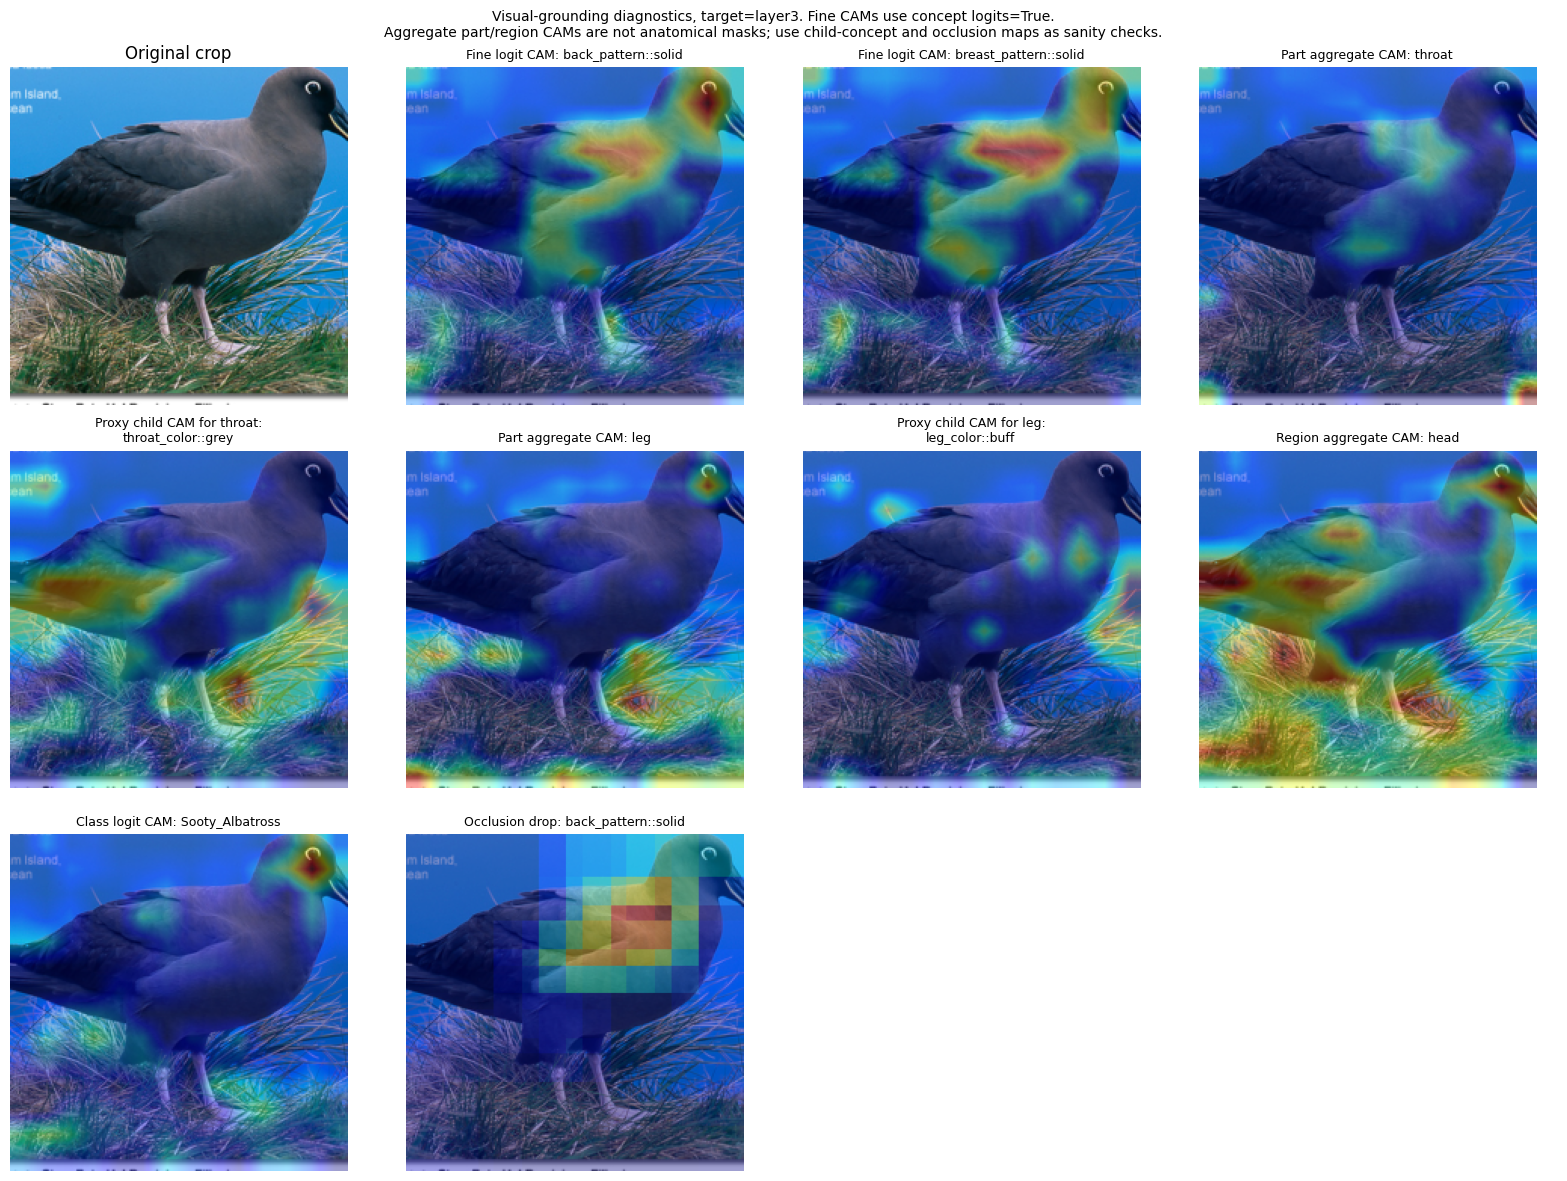

In [26]:

def inverse_normalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean, device=tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=tensor.device).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def get_resnet_target_layer(model, layer_name=GRADCAM_LAYER):
    if not hasattr(model, 'backbone'):
        raise ValueError('Model has no backbone attribute.')
    if isinstance(model.backbone, nn.Sequential):
        raise ValueError('Grad-CAM layer auto-selection is only configured for visual CBM ResNet backbones, not WordNetCBM Sequential backbone.')
    if layer_name == 'layer3':
        return model.backbone.layer3[-1]
    if layer_name == 'layer4':
        return model.backbone.layer4[-1]
    raise ValueError("GRADCAM_LAYER must be 'layer3' or 'layer4'.")


def visual_cbm_raw_outputs(model, image_batch):
    """Return logits and concept quantities, including pre-sigmoid fine logits when possible.

    The previous Grad-CAM implementation targeted sigmoid probabilities. That can saturate and
    produce weak/generic maps. For fine concepts, targeting the pre-sigmoid concept logit is usually
    a better diagnostic of what image region increases that concept evidence.
    """
    fine_logits = model.backbone(image_batch)
    if isinstance(model, ConceptBottleneckModel):
        fine = torch.sigmoid(fine_logits)
        class_logits = model.label_predictor(fine)
        return {'class_logits': class_logits, 'fine_logits': fine_logits, 'fine': fine, 'part': None, 'region': None}
    if isinstance(model, MeanHierarchicalCBM):
        fine = torch.sigmoid(fine_logits)
        part = (fine @ model.M_fine.T) / model.cnt_parts.T
        region = (part @ model.M_coarse.T) / model.cnt_regions.T
        class_logits = model.label_predictor(torch.cat([part, region], dim=1))
        return {'class_logits': class_logits, 'fine_logits': fine_logits, 'fine': fine, 'part': part, 'region': region}
    if isinstance(model, LearnableHierarchicalCBM):
        fine = torch.sigmoid(fine_logits)
        part, region = model.aggregate(fine)
        class_logits = model.label_predictor(torch.cat([fine, part, region], dim=1))
        return {'class_logits': class_logits, 'fine_logits': fine_logits, 'fine': fine, 'part': part, 'region': region}
    raise ValueError(f'Unsupported visual model type: {type(model)}')


class GradCAM:
    def __init__(self, model, target_layer=None):
        self.model = model
        self.model.eval()
        if target_layer is None:
            target_layer = get_resnet_target_layer(model, GRADCAM_LAYER)
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def __call__(self, image_tensor, target_type='class', target_index=None, positive_only=True):
        self.model.zero_grad(set_to_none=True)
        image_tensor = image_tensor.to(device).unsqueeze(0).requires_grad_(True)
        out = visual_cbm_raw_outputs(self.model, image_tensor)

        if target_type == 'class':
            logits = out['class_logits']
            if target_index is None:
                target_index = int(logits.argmax(dim=1).item())
            scalar = logits[0, target_index]
        elif target_type == 'fine':
            scalar = out['fine_logits'][0, target_index] if GRADCAM_USE_CONCEPT_LOGITS else out['fine'][0, target_index]
        elif target_type == 'part':
            if out['part'] is None:
                raise ValueError('Model does not output part concepts.')
            scalar = out['part'][0, target_index]
        elif target_type == 'region':
            if out['region'] is None:
                raise ValueError('Model does not output region concepts.')
            scalar = out['region'][0, target_index]
        else:
            raise ValueError(f'Unknown target_type: {target_type}')

        scalar.backward(retain_graph=False)
        if self.gradients is None or self.activations is None:
            raise RuntimeError('Grad-CAM hooks did not capture activations/gradients.')
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        if positive_only:
            cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
        cam = cam[0, 0]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy()


def overlay_heatmap(ax, image_np, heatmap, title='', cmap='jet', alpha=0.38):
    ax.imshow(image_np)
    ax.imshow(heatmap, cmap=cmap, alpha=alpha)
    ax.set_title(title, fontsize=9)
    ax.axis('off')


def load_image_tensor_from_result(res, sample_idx):
    img_id = res['img_ids'][sample_idx]
    row = master_df[master_df['img_id'] == img_id].iloc[0]
    path = os.path.join(CUB_DIR, 'images', row['filepath'])
    img = Image.open(path).convert('RGB')
    return test_transform(img), img


def select_grounded_fine_concepts(res, sample_idx, k=3, prefer_parts=None):
    if res.get('fine_pred') is None:
        return None
    fine_pred = res['fine_pred'][sample_idx]
    fine_true = res['fine_true'][sample_idx]
    mask = np.ones_like(fine_pred, dtype=bool)
    if prefer_parts is not None:
        part_set = set(prefer_parts)
        part_arr = hierarchy_df.sort_values('attr_id')['part'].values
        mask = np.array([p in part_set for p in part_arr])
    candidates = np.where((fine_true >= 0.5) & (fine_pred >= FINE_THRESHOLD) & mask)[0]
    mode = 'GT-present and predicted-active'
    if len(candidates) == 0:
        candidates = np.where((fine_true >= 0.5) & mask)[0]
        mode = 'GT-present fallback'
    if len(candidates) == 0:
        candidates = np.where(mask)[0]
        candidates = candidates[np.argsort(fine_pred[candidates])[::-1][:k]] if len(candidates) > 0 else np.argsort(fine_pred)[::-1][:k]
        mode = 'top-predicted fallback'
    candidates = sorted(candidates, key=lambda j: fine_pred[j], reverse=True)[:k]
    return candidates, mode


def select_grounded_parent_concepts(res, sample_idx, level='part', k=3):
    pred_key = f'{level}_pred'
    true_key = f'{level}_true'
    threshold = PART_THRESHOLD if level == 'part' else REGION_THRESHOLD
    if res.get(pred_key) is None:
        return None
    pred = res[pred_key][sample_idx]
    true = res[true_key][sample_idx]
    candidates = np.where((true >= 0.5) & (pred >= threshold))[0]
    mode = 'GT-present and predicted-active'
    if len(candidates) == 0:
        candidates = np.where(true >= 0.5)[0]
        mode = 'GT-present fallback'
    if len(candidates) == 0:
        candidates = np.argsort(pred)[::-1][:k]
        mode = 'top-predicted fallback'
    candidates = sorted(candidates, key=lambda j: pred[j], reverse=True)[:k]
    return candidates, mode


def select_fine_concepts_for_part(res, sample_idx, part_idx, k=2):
    part_name = hier_parts[part_idx]
    selected = select_grounded_fine_concepts(res, sample_idx, k=k, prefer_parts=[part_name])
    return selected[0] if selected is not None else []


def occlusion_sensitivity_map(model, image_tensor, target_type='fine', target_index=None,
                              grid=OCCLUSION_GRID, patch_size=OCCLUSION_PATCH):
    """Patch-occlusion map: drop in target score when a patch is replaced by the ImageNet mean.

    This is slower than Grad-CAM but is a useful sanity check because it directly perturbs input pixels.
    It still does not prove semantic grounding, especially because CUB concepts are image-level labels.
    """
    model.eval()
    x = image_tensor.to(device).unsqueeze(0)
    with torch.no_grad():
        out = visual_cbm_raw_outputs(model, x)
        if target_type == 'class':
            if target_index is None:
                target_index = int(out['class_logits'].argmax(dim=1).item())
            base = out['class_logits'][0, target_index]
        elif target_type == 'fine':
            base = out['fine_logits'][0, target_index] if GRADCAM_USE_CONCEPT_LOGITS else out['fine'][0, target_index]
        elif target_type == 'part':
            base = out['part'][0, target_index]
        elif target_type == 'region':
            base = out['region'][0, target_index]
        else:
            raise ValueError(target_type)

    h = w = IMAGE_SIZE
    ys = np.linspace(0, h - patch_size, grid).astype(int)
    xs = np.linspace(0, w - patch_size, grid).astype(int)
    heat = torch.zeros((h, w), device=device)
    count = torch.zeros((h, w), device=device)
    fill = torch.tensor([(0.0 - IMAGENET_MEAN[c]) / IMAGENET_STD[c] for c in range(3)], device=device).view(1, 3, 1, 1)

    with torch.no_grad():
        for y0 in ys:
            for x0 in xs:
                x_occ = x.clone()
                x_occ[:, :, y0:y0 + patch_size, x0:x0 + patch_size] = fill
                out_occ = visual_cbm_raw_outputs(model, x_occ)
                if target_type == 'class':
                    score = out_occ['class_logits'][0, target_index]
                elif target_type == 'fine':
                    score = out_occ['fine_logits'][0, target_index] if GRADCAM_USE_CONCEPT_LOGITS else out_occ['fine'][0, target_index]
                elif target_type == 'part':
                    score = out_occ['part'][0, target_index]
                elif target_type == 'region':
                    score = out_occ['region'][0, target_index]
                drop = torch.relu(base - score)
                heat[y0:y0 + patch_size, x0:x0 + patch_size] += drop
                count[y0:y0 + patch_size, x0:x0 + patch_size] += 1
    heat = heat / count.clamp(min=1)
    heat = heat - heat.min()
    heat = heat / (heat.max() + 1e-8)
    return heat.detach().cpu().numpy()


def plot_gradcam_panel(model, res, sample_idx, fine_indices=None, part_indices=None, region_indices=None,
                       save_name=None, layer_name=GRADCAM_LAYER, include_part_proxy=True, include_occlusion=True):
    if isinstance(model, WordNetCBM):
        print('Grad-CAM panel skipped for WordNetCBM in this notebook.')
        return
    image_tensor, pil_img = load_image_tensor_from_result(res, sample_idx)
    image_np = inverse_normalize(image_tensor).permute(1, 2, 0).cpu().numpy()

    target_layer = get_resnet_target_layer(model, layer_name)
    cam = GradCAM(model, target_layer=target_layer)
    panels = [('Original crop', None, None, 'image')]
    if fine_indices is not None:
        for idx in fine_indices:
            name = attrs_df.iloc[idx]['attr_name'].replace('has_', '')
            panels.append((f'Fine logit CAM: {name}', 'fine', idx, 'cam'))
    if part_indices is not None:
        for idx in part_indices:
            # Parent part CAMs are aggregate evidence maps. They should not be read as clean part-localization masks.
            panels.append((f'Part aggregate CAM: {hier_parts[idx]}', 'part', idx, 'cam'))
            if include_part_proxy:
                child_idxs = select_fine_concepts_for_part(res, sample_idx, idx, k=1)
                for cidx in child_idxs[:1]:
                    cname = attrs_df.iloc[cidx]['attr_name'].replace('has_', '')
                    panels.append((f'Proxy child CAM for {hier_parts[idx]}:\n{cname}', 'fine', cidx, 'cam'))
    if region_indices is not None:
        for idx in region_indices:
            panels.append((f'Region aggregate CAM: {hier_regions[idx]}', 'region', idx, 'cam'))
    pred = int(res['y_pred'][sample_idx])
    panels.append((f'Class logit CAM: {class_label_name(pred).split(".")[-1]}', 'class', pred, 'cam'))

    # Add one perturbation sanity map for the first selected fine concept. This often answers whether
    # the CAM is a gradient artifact or whether removing that area actually changes the target score.
    if include_occlusion and RUN_OCCLUSION_VISUAL_CHECK and fine_indices is not None and len(fine_indices) > 0:
        cidx = int(fine_indices[0])
        cname = attrs_df.iloc[cidx]['attr_name'].replace('has_', '')
        panels.append((f'Occlusion drop: {cname}', 'fine', cidx, 'occlusion'))

    n = len(panels)
    cols = min(4, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (title, typ, idx, mode) in zip(axes, panels):
        if typ is None:
            ax.imshow(image_np)
            ax.set_title(title)
            ax.axis('off')
        else:
            try:
                if mode == 'occlusion':
                    heat = occlusion_sensitivity_map(model, image_tensor, target_type=typ, target_index=idx)
                else:
                    heat = cam(image_tensor, target_type=typ, target_index=idx)
                overlay_heatmap(ax, image_np, heat, title=title)
            except Exception as e:
                ax.imshow(image_np)
                ax.set_title(f'{title}\nfailed: {e}', fontsize=8)
                ax.axis('off')
    for ax in axes[len(panels):]:
        ax.axis('off')
    plt.suptitle(
        f'Visual-grounding diagnostics, target={layer_name}. Fine CAMs use concept logits={GRADCAM_USE_CONCEPT_LOGITS}.\n'
        'Aggregate part/region CAMs are not anatomical masks; use child-concept and occlusion maps as sanity checks.',
        fontsize=10,
    )
    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(EVAL_DIR, save_name), dpi=180, bbox_inches='tight')
    plt.show()
    cam.remove()


# Example panel: select GT-present concepts when possible, rather than arbitrary top predictions.
if len(results) > 0 and main_model_name in models_to_eval and not isinstance(models_to_eval[main_model_name], WordNetCBM):
    res = results[main_model_name]
    idx = list(find_example_indices(res).values())[0]

    fine_selection = select_grounded_fine_concepts(res, idx, k=2)
    part_selection = select_grounded_parent_concepts(res, idx, level='part', k=2)
    region_selection = select_grounded_parent_concepts(res, idx, level='region', k=1)

    fine_indices = fine_selection[0] if fine_selection is not None else None
    part_indices = part_selection[0] if part_selection is not None else None
    region_indices = region_selection[0] if region_selection is not None else None

    print('Fine Grad-CAM selection:', None if fine_selection is None else fine_selection[1])
    print('Part Grad-CAM selection:', None if part_selection is None else part_selection[1])
    print('Region Grad-CAM selection:', None if region_selection is None else region_selection[1])
    print('Note: CUB concepts are image-level annotations, not part masks. Bad localization is a valid diagnostic, not necessarily a plotting bug.')

    plot_gradcam_panel(models_to_eval[main_model_name], res, idx, fine_indices, part_indices, region_indices,
                       save_name=f'{main_model_name.replace(" ", "_")}_visual_grounding_diagnostics_{GRADCAM_LAYER}.png',
                       layer_name=GRADCAM_LAYER,
                       include_part_proxy=True,
                       include_occlusion=True)



### Visual-grounding interpretation and model-level limitation
The CUB attributes used here are **image-level labels**. They say that an image has, for example, `bill_color::yellow`, but they do not supervise the network to look at the bill pixels. Therefore the concept head can learn class-correlated shortcuts such as global plumage, pose, or background.


## 16. Faithfulness by concept removal

If an explanation is faithful, removing the most influential concepts should reduce the model confidence or accuracy. This section performs concept removal on models whose classifier can be re-run from concept vectors.

In [27]:
def classify_from_fine_concepts(model, fine):
    # Recompute class logits from a modified fine-concept vector.
    if isinstance(model, ConceptBottleneckModel):
        return model.label_predictor(fine)
    if isinstance(model, MeanHierarchicalCBM):
        mid = (fine @ model.M_fine.T) / model.cnt_parts.T
        coarse = (mid @ model.M_coarse.T) / model.cnt_regions.T
        return model.label_predictor(torch.cat([mid, coarse], dim=1))
    if isinstance(model, LearnableHierarchicalCBM):
        mid, coarse = model.aggregate(fine)
        return model.label_predictor(torch.cat([fine, mid, coarse], dim=1))
    raise ValueError('Unsupported model type for concept-level reclassification.')


def concept_importance_by_gradient(model, fine_batch, target_classes):
    fine = fine_batch.clone().detach().to(device).requires_grad_(True)
    logits = classify_from_fine_concepts(model, fine)
    score = logits[torch.arange(logits.size(0), device=device), target_classes.to(device)].sum()
    model.zero_grad(set_to_none=True)
    if fine.grad is not None:
        fine.grad.zero_()
    score.backward()
    importance = (fine.grad.abs() * fine.detach()).detach()
    return importance


def evaluate_concept_removal(model, res, ks=(1, 5, 10, 20, 50), max_batches=None):
    if res.get('fine_pred') is None or isinstance(model, WordNetCBM):
        return None
    model.eval()
    y_true = torch.tensor(res['y_true'], dtype=torch.long)
    fine_pred = torch.tensor(res['fine_pred'], dtype=torch.float32)
    baseline_logits = []
    with torch.no_grad():
        for start in range(0, len(fine_pred), BATCH_SIZE):
            logits = classify_from_fine_concepts(model, fine_pred[start:start+BATCH_SIZE].to(device))
            baseline_logits.append(logits.cpu())
    baseline_logits = torch.cat(baseline_logits, dim=0)
    baseline_pred = baseline_logits.argmax(dim=1)
    baseline_acc = (baseline_pred == y_true).float().mean().item()
    baseline_conf = torch.softmax(baseline_logits, dim=1).max(dim=1).values.mean().item()

    rows = [{'k_removed': 0, 'accuracy': baseline_acc, 'mean_confidence': baseline_conf}]
    for k in ks:
        all_logits = []
        for start in range(0, len(fine_pred), BATCH_SIZE):
            end = start + BATCH_SIZE
            fine_b = fine_pred[start:end].to(device)
            target_b = baseline_pred[start:end].to(device)
            imp = concept_importance_by_gradient(model, fine_b, target_b)
            topk = imp.topk(k=min(k, imp.shape[1]), dim=1).indices
            masked = fine_b.clone()
            masked.scatter_(1, topk, 0.0)
            with torch.no_grad():
                logits = classify_from_fine_concepts(model, masked)
            all_logits.append(logits.cpu())
        logits_removed = torch.cat(all_logits, dim=0)
        pred_removed = logits_removed.argmax(dim=1)
        acc = (pred_removed == y_true).float().mean().item()
        conf = torch.softmax(logits_removed, dim=1).max(dim=1).values.mean().item()
        rows.append({'k_removed': k, 'accuracy': acc, 'mean_confidence': conf})
    return pd.DataFrame(rows)

removal_results = {}
for name, model in models_to_eval.items():
    try:
        df = evaluate_concept_removal(model, results[name], ks=(1, 5, 10, 20, 50))
        if df is not None:
            removal_results[name] = df
            df.to_csv(os.path.join(EVAL_DIR, f'{name.replace(" ", "_")}_concept_removal.csv'), index=False)
    except Exception as e:
        print(f'Concept removal skipped for {name}: {e}')

for name, df in removal_results.items():
    print('\n', name)
    display(df.style.format({'accuracy': '{:.4f}', 'mean_confidence': '{:.4f}'}))



 Flat CBM


,k_removed,accuracy,mean_confidence
0,0,0.8010,0.7514
1,1,0.7988,0.7293
2,5,0.7900,0.6471
3,10,0.7734,0.5379
4,20,0.7237,0.3126
5,50,0.2860,0.0418



 Mean Hier-CBM


,k_removed,accuracy,mean_confidence
0,0,0.6367,0.2590
1,1,0.6331,0.2490
2,5,0.5689,0.2039
3,10,0.5425,0.1624
4,20,0.4389,0.1007
5,50,0.0982,0.0404



 Learnable Hier-CBM


,k_removed,accuracy,mean_confidence
0,0,0.7289,0.7841
1,1,0.7261,0.7610
2,5,0.6795,0.6864
3,10,0.5174,0.5716
4,20,0.2532,0.4422
5,50,0.0827,0.2093


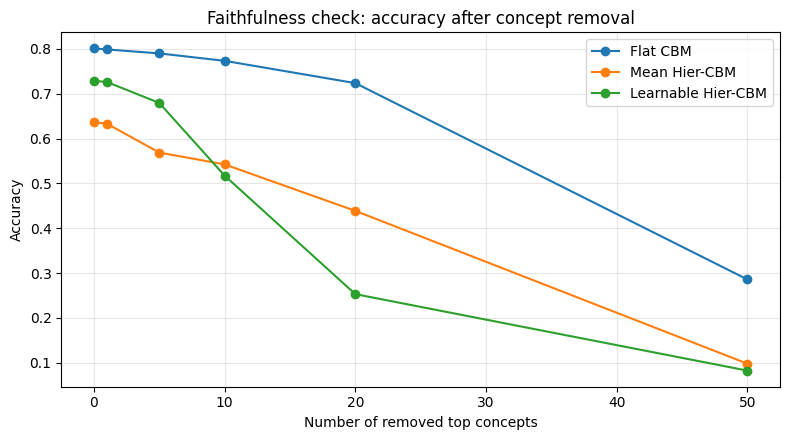

In [28]:
def plot_removal_curves(removal_results):
    if not removal_results:
        print('No removal results to plot.')
        return
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for name, df in removal_results.items():
        ax.plot(df['k_removed'], df['accuracy'], marker='o', label=name)
    ax.set_xlabel('Number of removed top concepts')
    ax.set_ylabel('Accuracy')
    ax.set_title('Faithfulness check: accuracy after concept removal')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_DIR, 'concept_removal_accuracy_curves.png'), dpi=180, bbox_inches='tight')
    plt.show()

plot_removal_curves(removal_results)

## 17. Intervention evaluation with oracle concepts

This checks whether correcting concepts improves classification. A strong CBM should generally benefit when predicted concepts are replaced with ground-truth concepts.

In [29]:
def make_calibrated_oracle_from_test_distribution(fine_pred, fine_true, eps=1e-6):
    """Map GT 0/1 concepts to concept probabilities resembling the model's own score distribution.

    This reduces the distribution shift of feeding raw binary GT concepts to a class head trained on
    predicted probabilities. For each concept j:
      GT=1 -> mean predicted score among GT-positive test samples for concept j
      GT=0 -> mean predicted score among GT-negative test samples for concept j
    """
    fine_pred = torch.tensor(fine_pred, dtype=torch.float32)
    fine_true = torch.tensor(fine_true, dtype=torch.float32)
    pos_count = fine_true.sum(dim=0).clamp(min=eps)
    neg_count = (1 - fine_true).sum(dim=0).clamp(min=eps)
    pos_mean = (fine_pred * fine_true).sum(dim=0) / pos_count
    neg_mean = (fine_pred * (1 - fine_true)).sum(dim=0) / neg_count
    oracle_like = torch.where(fine_true > 0.5, pos_mean, neg_mean)
    return oracle_like.clamp(0, 1)

def partially_correct_concepts(fine_pred, fine_true, k):
    """Correct the k most wrong concepts per sample, keeping the rest as predicted probabilities."""
    fine_pred = torch.tensor(fine_pred, dtype=torch.float32)
    fine_true = torch.tensor(fine_true, dtype=torch.float32)
    error = torch.abs(fine_pred - fine_true)
    out = fine_pred.clone()
    if k <= 0:
        return out
    topk = error.topk(k=min(k, error.shape[1]), dim=1).indices
    out.scatter_(1, topk, fine_true.gather(1, topk))
    return out

def logits_from_fine_source(model, fine_source):
    logits_all = []
    with torch.no_grad():
        for start in range(0, len(fine_source), BATCH_SIZE):
            logits = classify_from_fine_concepts(model, fine_source[start:start+BATCH_SIZE].to(device))
            logits_all.append(logits.cpu())
    return torch.cat(logits_all, dim=0)

def evaluate_fine_oracle_intervention(model, res):
    if res.get('fine_pred') is None or isinstance(model, WordNetCBM):
        return None
    y_true = torch.tensor(res['y_true'], dtype=torch.long)
    fine_pred = torch.tensor(res['fine_pred'], dtype=torch.float32)
    fine_true = torch.tensor(res['fine_true'], dtype=torch.float32)
    fine_calibrated_oracle = make_calibrated_oracle_from_test_distribution(res['fine_pred'], res['fine_true'])

    rows = []
    settings = {
        'predicted fine concepts (in-distribution)': fine_pred,
        'calibrated oracle concepts (less OOD)': fine_calibrated_oracle,
        'raw binary GT concepts (OOD diagnostic)': fine_true,
    }
    for label, fine_source in settings.items():
        logits_all = logits_from_fine_source(model, fine_source)
        pred = logits_all.argmax(dim=1)
        rows.append({
            'Setting': label,
            'Accuracy': (pred == y_true).float().mean().item(),
            'Mean Confidence': torch.softmax(logits_all, dim=1).max(dim=1).values.mean().item(),
        })

    # Partial intervention curve: correct only the most wrong concepts per sample.
    for k in [1, 5, 10, 20, 50, 100, 312]:
        fine_partial = partially_correct_concepts(fine_pred, fine_true, k)
        logits_all = logits_from_fine_source(model, fine_partial)
        pred = logits_all.argmax(dim=1)
        rows.append({
            'Setting': f'partial correction: top-{k} most wrong concepts',
            'Accuracy': (pred == y_true).float().mean().item(),
            'Mean Confidence': torch.softmax(logits_all, dim=1).max(dim=1).values.mean().item(),
        })
    return pd.DataFrame(rows)

def train_and_evaluate_gt_concept_probe(res_by_model):
    """Train an independent, simple concept->species classifier on GT train concepts.

    This gives a cleaner upper-bound question than feeding binary GT concepts into a class head
    trained on predicted concept probabilities. It evaluates whether the CUB concept annotation
    space itself contains enough information for species classification.
    """
    train_df = master_df[master_df['is_train'] == 1].copy()
    test_df = master_df[master_df['is_train'] == 0].copy()
    X_train = concept_matrix.loc[train_df['img_id'].values].values.astype(np.float32)
    y_train = train_df['label'].values.astype(int)
    X_test_gt = concept_matrix.loc[test_df['img_id'].values].values.astype(np.float32)
    y_test = test_df['label'].values.astype(int)

    probe = make_pipeline(
        StandardScaler(with_mean=False),
        RidgeClassifier(alpha=1.0)
    )
    probe.fit(X_train, y_train)

    rows = []
    gt_pred = probe.predict(X_test_gt)
    rows.append({
        'Input': 'GT concepts -> independent Ridge probe',
        'Accuracy': accuracy_score(y_test, gt_pred),
        'Balanced Acc': balanced_accuracy_score(y_test, gt_pred),
        'Macro-F1': f1_score(y_test, gt_pred, average='macro', zero_division=0),
    })

    # Feed each model's predicted concepts into the same probe, if the sample order matches test_df.
    expected_img_ids = test_df['img_id'].astype(int).tolist()
    for name, res in res_by_model.items():
        if res.get('fine_pred') is None:
            continue
        if res['img_ids'] != expected_img_ids:
            print(f'Probe skipped for {name}: result img_id order differs from test split order.')
            continue
        pred = probe.predict(res['fine_pred'].astype(np.float32))
        rows.append({
            'Input': f'{name} predicted concepts -> same Ridge probe',
            'Accuracy': accuracy_score(y_test, pred),
            'Balanced Acc': balanced_accuracy_score(y_test, pred),
            'Macro-F1': f1_score(y_test, pred, average='macro', zero_division=0),
        })
    return pd.DataFrame(rows)

intervention_results = {}
for name, model in models_to_eval.items():
    try:
        df = evaluate_fine_oracle_intervention(model, results[name])
        if df is not None:
            intervention_results[name] = df
            df.to_csv(os.path.join(EVAL_DIR, f'{name.replace(" ", "_")}_fine_oracle_intervention_fixed.csv'), index=False)
    except Exception as e:
        print(f'Intervention skipped for {name}: {e}')

for name, df in intervention_results.items():
    print('\n', name)
    display(df.style.format({'Accuracy': '{:.4f}', 'Mean Confidence': '{:.4f}'}))

if RUN_GT_CONCEPT_PROBE:
    try:
        gt_probe_df = train_and_evaluate_gt_concept_probe(results)
        gt_probe_df.to_csv(os.path.join(EVAL_DIR, 'gt_concept_probe.csv'), index=False)
        print('\nIndependent GT-concept probe:')
        display(gt_probe_df.style.format({c: '{:.4f}' for c in gt_probe_df.columns if c != 'Input'}))
    except Exception as e:
        gt_probe_df = pd.DataFrame()
        print('GT-concept probe skipped:', e)
else:
    gt_probe_df = pd.DataFrame()


C:\Users\elzia\AppData\Local\Temp\ipykernel_7468\3443458135.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fine_pred = torch.tensor(fine_pred, dtype=torch.float32)
C:\Users\elzia\AppData\Local\Temp\ipykernel_7468\3443458135.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fine_true = torch.tensor(fine_true, dtype=torch.float32)



 Flat CBM


,Setting,Accuracy,Mean Confidence
0,predicted fine concepts (in-distribution),0.8010,0.7514
1,calibrated oracle concepts (less OOD),0.0238,0.0164
2,raw binary GT concepts (OOD diagnostic),0.0613,0.0650
3,partial correction: top-1 most wrong concepts,0.8015,0.7440
4,partial correction: top-5 most wrong concepts,0.8000,0.7058
5,partial correction: top-10 most wrong concepts,0.7991,0.6388
6,partial correction: top-20 most wrong concepts,0.7906,0.4530
7,partial correction: top-50 most wrong concepts,0.4487,0.0776
8,partial correction: top-100 most wrong concepts,0.0340,0.0525
9,partial correction: top-312 most wrong concepts,0.0613,0.0650



 Mean Hier-CBM


,Setting,Accuracy,Mean Confidence
0,predicted fine concepts (in-distribution),0.6367,0.2590
1,calibrated oracle concepts (less OOD),0.0055,0.0126
2,raw binary GT concepts (OOD diagnostic),0.0060,0.0104
3,partial correction: top-1 most wrong concepts,0.6329,0.2518
4,partial correction: top-5 most wrong concepts,0.6298,0.2264
5,partial correction: top-10 most wrong concepts,0.6187,0.1962
6,partial correction: top-20 most wrong concepts,0.5713,0.1359
7,partial correction: top-50 most wrong concepts,0.2639,0.0400
8,partial correction: top-100 most wrong concepts,0.0052,0.0138
9,partial correction: top-312 most wrong concepts,0.0060,0.0104



 Learnable Hier-CBM


,Setting,Accuracy,Mean Confidence
0,predicted fine concepts (in-distribution),0.7289,0.7841
1,calibrated oracle concepts (less OOD),0.0243,0.2972
2,raw binary GT concepts (OOD diagnostic),0.0908,0.4241
3,partial correction: top-1 most wrong concepts,0.7311,0.7798
4,partial correction: top-5 most wrong concepts,0.7116,0.7573
5,partial correction: top-10 most wrong concepts,0.6659,0.7137
6,partial correction: top-20 most wrong concepts,0.5074,0.6030
7,partial correction: top-50 most wrong concepts,0.1667,0.4450
8,partial correction: top-100 most wrong concepts,0.0891,0.4108
9,partial correction: top-312 most wrong concepts,0.0908,0.4241



Independent GT-concept probe:


,Input,Accuracy,Balanced Acc,Macro-F1
0,GT concepts -> independent Ridge probe,0.3638,0.3652,0.3271
1,Flat CBM predicted concepts -> same Ridge probe,0.0509,0.0518,0.0288
2,Mean Hier-CBM predicted concepts -> same Ridge probe,0.0059,0.0057,0.0018
3,Learnable Hier-CBM predicted concepts -> same Ridge probe,0.0908,0.0947,0.0538


## 18. Hierarchy-conditioned concept discriminativeness

This section adds two complementary analyses.

First, it performs a **dataset-level preliminary analysis** using ground-truth CUB attributes. This asks whether the annotation space itself contains concepts that are discriminative at different taxonomic levels: family, genus, and species.

Second, it performs a **prediction-level concept relevance analysis** using the concepts predicted by each visual CBM. This asks whether the concepts actually used by the model become more specific when moving from coarse to fine taxonomic decisions.

The key hypothesis is: concepts that are useful to separate families should often become less discriminative once we condition on that family, while more specific concepts should become relevant for genus/species decisions within the selected branch.

In [30]:

# ---------- Helpers for hierarchy-conditioned concept relevance ----------

attrs_ordered = attrs_df.sort_values('attr_id').reset_index(drop=True).copy()
concept_names = attrs_ordered['attr_name'].tolist()
concept_meta = hierarchy_df.sort_values('attr_id').reset_index(drop=True)[['attr_id', 'attr_name', 'part', 'region']].copy()

family_id_to_name = {v: k for k, v in family_to_id.items()}
genus_id_to_name = {v: k for k, v in genus_to_id.items()}
species_id_to_name = {int(row['class_id']) - 1: class_label_name(int(row['class_id']) - 1) for _, row in classes_df.iterrows()}


def add_taxonomy_columns(df):
    out = df.copy()
    out['species_id'] = out['label'].astype(int)
    out['species_name'] = out['species_id'].map(species_id_to_name)
    out['genus_id'] = out['species_id'].map(species_to_genus).astype(int)
    out['family_id'] = out['species_id'].map(species_to_family).astype(int)
    out['genus_name'] = out['genus_id'].map(genus_id_to_name)
    out['family_name'] = out['family_id'].map(family_id_to_name)
    return out


def add_concept_metadata(df):
    if df is None or len(df) == 0:
        return pd.DataFrame()
    out = df.copy()
    out['concept_idx'] = out['concept_idx'].astype(int)
    meta = concept_meta.copy()
    meta['concept_idx'] = meta['attr_id'].astype(int) - 1
    meta = meta[['concept_idx', 'part', 'region']]
    out = out.merge(meta, on='concept_idx', how='left')
    return out


def factorize_labels(y):
    y = np.asarray(y)
    codes, uniques = pd.factorize(y, sort=True)
    return codes.astype(int), uniques


def label_entropy(y_codes):
    vals, counts = np.unique(y_codes, return_counts=True)
    p = counts.astype(float) / counts.sum()
    return float(-(p * np.log(p + 1e-12)).sum())


def compute_mi_table(X, y, target_name, source_name, discrete_features=False):
    """Compute concept/target mutual information.

    `mi` is useful for ranking within one target. `normalized_mi = mi / H(target)` is safer
    when comparing family/genus/species because the number of classes differs across levels.
    """
    X = np.asarray(X, dtype=np.float32)
    y_codes, uniques = factorize_labels(y)
    valid = y_codes >= 0
    X = X[valid]
    y_codes = y_codes[valid]
    if X.shape[0] == 0 or len(np.unique(y_codes)) < 2:
        return pd.DataFrame(columns=['source', 'target', 'concept_idx', 'concept', 'mi', 'normalized_mi', 'rank'])

    mi = mutual_info_classif(
        X,
        y_codes,
        discrete_features=discrete_features,
        random_state=SEED,
    )
    H = label_entropy(y_codes)
    nmi = mi / max(H, 1e-12)
    df = pd.DataFrame({
        'source': source_name,
        'target': target_name,
        'concept_idx': np.arange(len(concept_names), dtype=int),
        'concept': concept_names,
        'mi': mi,
        'normalized_mi': nmi,
        'target_entropy': H,
    }).sort_values('mi', ascending=False).reset_index(drop=True)
    df['rank'] = np.arange(1, len(df) + 1)
    df['rank_normalized_mi'] = df['normalized_mi'].rank(method='first', ascending=False).astype(int)
    df['n_samples'] = int(X.shape[0])
    df['n_target_classes'] = int(len(np.unique(y_codes)))
    return add_concept_metadata(df)


def conditional_top_mi_by_group(
    X,
    coarse_labels,
    fine_labels,
    coarse_level_name,
    fine_level_name,
    source_name,
    group_name_map=None,
    fine_name_map=None,
    discrete_features=False,
    min_samples=MIN_CONDITIONAL_SAMPLES,
    min_classes=MIN_CONDITIONAL_CLASSES,
    top_k=CONDITIONAL_MI_TOP_K,
):
    """Within each coarse group, find concepts most informative for distinguishing finer labels."""
    X = np.asarray(X, dtype=np.float32)
    coarse_labels = np.asarray(coarse_labels)
    fine_labels = np.asarray(fine_labels)
    rows = []
    for group in sorted(np.unique(coarse_labels)):
        idx = np.where(coarse_labels == group)[0]
        if len(idx) < min_samples:
            continue
        y_sub = fine_labels[idx]
        if len(np.unique(y_sub)) < min_classes:
            continue

        target_name = f'{fine_level_name}_within_{coarse_level_name}'
        mi_df = compute_mi_table(
            X[idx],
            y_sub,
            target_name=target_name,
            source_name=source_name,
            discrete_features=discrete_features,
        ).head(top_k).copy()
        if len(mi_df) == 0:
            continue
        mi_df.insert(0, 'coarse_level', coarse_level_name)
        mi_df.insert(1, 'fine_level', fine_level_name)
        mi_df.insert(2, 'group_id', int(group) if np.issubdtype(type(group), np.integer) or str(group).isdigit() else group)
        mi_df.insert(3, 'group_name', group_name_map.get(int(group), str(group)) if group_name_map is not None else str(group))
        mi_df['conditional_rank'] = np.arange(1, len(mi_df) + 1)
        mi_df['conditional_n_samples'] = len(idx)
        mi_df['conditional_n_classes'] = len(np.unique(y_sub))
        rows.append(mi_df)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def jaccard(a, b):
    a, b = set(a), set(b)
    if len(a | b) == 0:
        return np.nan
    return len(a & b) / len(a | b)


def summarize_conditional_overlap(global_top_df, conditional_df, global_name, conditional_name, top_k=MI_TOP_K):
    if global_top_df is None or len(global_top_df) == 0 or conditional_df is None or len(conditional_df) == 0:
        return pd.DataFrame()
    global_set = set(global_top_df.head(top_k)['concept_idx'].astype(int))
    rows = []
    for (gid, gname), gdf in conditional_df.groupby(['group_id', 'group_name']):
        cond_set = set(gdf.head(top_k)['concept_idx'].astype(int))
        rows.append({
            'global_reference': global_name,
            'conditional_reference': conditional_name,
            'group_id': gid,
            'group_name': gname,
            'global_top_k': top_k,
            'conditional_top_k': min(top_k, len(gdf)),
            'jaccard_overlap': jaccard(global_set, cond_set),
            'n_shared_concepts': len(global_set & cond_set),
        })
    return pd.DataFrame(rows).sort_values('jaccard_overlap')


def overlap_numeric_summary(overlap_df):
    if overlap_df is None or len(overlap_df) == 0:
        return pd.DataFrame()
    return overlap_df[['jaccard_overlap', 'n_shared_concepts', 'conditional_top_k']].describe().T


def cross_level_peak_table(mi_tables, source_name, score_col='normalized_mi'):
    """Merge family/genus/species MI and identify at which level each concept peaks.

    Uses normalized MI by default, because raw MI is biased upward for taxonomic levels with
    many classes, especially species.
    """
    required = ['family', 'genus', 'species']
    if any(k not in mi_tables or len(mi_tables[k]) == 0 for k in required):
        return pd.DataFrame()
    base = concept_meta.copy()
    base['concept_idx'] = base['attr_id'].astype(int) - 1
    base = base[['concept_idx', 'attr_name', 'part', 'region']].rename(columns={'attr_name': 'concept'})
    out = base.copy()
    for level in required:
        tmp = mi_tables[level][['concept_idx', 'mi', 'normalized_mi', 'rank']].rename(
            columns={'mi': f'mi_{level}', 'normalized_mi': f'normalized_mi_{level}', 'rank': f'rank_{level}'}
        )
        out = out.merge(tmp, on='concept_idx', how='left')
    score_cols = [f'{score_col}_{k}' for k in required]
    out[score_cols] = out[score_cols].fillna(0.0)
    out['peak_level'] = out[score_cols].idxmax(axis=1).str.replace(f'{score_col}_', '', regex=False)
    out['peak_score'] = out[score_cols].max(axis=1)
    out['peak_score_type'] = score_col
    out['source'] = source_name
    return out.sort_values('peak_score', ascending=False).reset_index(drop=True)


def display_top_concepts(df, title, n=20):
    print('\n' + title)
    if df is None or len(df) == 0:
        print('No rows to display.')
        return
    cols = [c for c in ['rank', 'conditional_rank', 'concept', 'part', 'region', 'mi', 'normalized_mi', 'n_samples', 'n_target_classes', 'group_name', 'conditional_n_samples', 'conditional_n_classes'] if c in df.columns]
    display(df.head(n)[cols].style.format({'mi': '{:.5f}', 'normalized_mi': '{:.5f}'}, na_rep='N/A'))


def plot_top_concepts(df, title, filename=None, n=15, score_col='mi'):
    if df is None or len(df) == 0:
        print(f'No data for plot: {title}')
        return
    if score_col not in df.columns:
        score_col = 'mi'
    top = df.sort_values(score_col, ascending=False).head(n).iloc[::-1]
    labels = top['concept'].astype(str).str.replace('has_', '', regex=False)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.42 * n)))
    ax.barh(labels, top[score_col])
    ax.set_xlabel(score_col.replace('_', ' '))
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(top[score_col].values):
        ax.text(v, i, f' {v:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    if filename:
        plt.savefig(os.path.join(EVAL_DIR, filename), dpi=200, bbox_inches='tight')
    plt.show()


### 18.1 Preliminary dataset analysis: are CUB concepts discriminative at different taxonomy levels?

This part uses **ground-truth CUB concepts**, not model predictions. It is a sanity check on the dataset: before asking whether a model learns hierarchy-aware explanations, we verify whether the annotation space contains concepts that are informative for family, genus, and species labels.

The conditional analyses are the most important ones:

- `genus within family`: after fixing the family, which concepts distinguish genera?
- `species within genus`: after fixing the genus, which concepts distinguish species?

Low overlap between global family concepts and within-family concepts supports the idea that explanations should change across hierarchy levels.

,quantity,value
0,families,62.000000
1,genera,109.000000
2,species,200.000000
3,mean genera per family,1.774194
4,mean species per genus,1.834862
5,train images,5994.000000
6,test images,5794.000000



GT concepts: top concepts for family


,rank,concept,part,region,mi,normalized_mi,n_samples,n_target_classes
0,1,has_bill_length::shorter_than_head,bill,head,0.20676,0.06155,5994,62
1,2,has_bill_shape::cone,bill,head,0.18050,0.05374,5994,62
2,3,has_shape::perching-like,shape,other,0.17521,0.05216,5994,62
3,4,has_bill_length::about_the_same_as_head,bill,head,0.15950,0.04748,5994,62
4,5,has_throat_color::white,throat,head,0.15269,0.04546,5994,62
5,6,has_underparts_color::yellow,underparts,lower,0.14924,0.04443,5994,62
6,7,has_size::medium_(9_-_16_in),size,other,0.14735,0.04387,5994,62
7,8,has_belly_color::yellow,belly,body,0.13935,0.04148,5994,62
8,9,has_bill_shape::all-purpose,bill,head,0.13596,0.04048,5994,62
9,10,has_primary_color::yellow,primary,other,0.13313,0.03963,5994,62


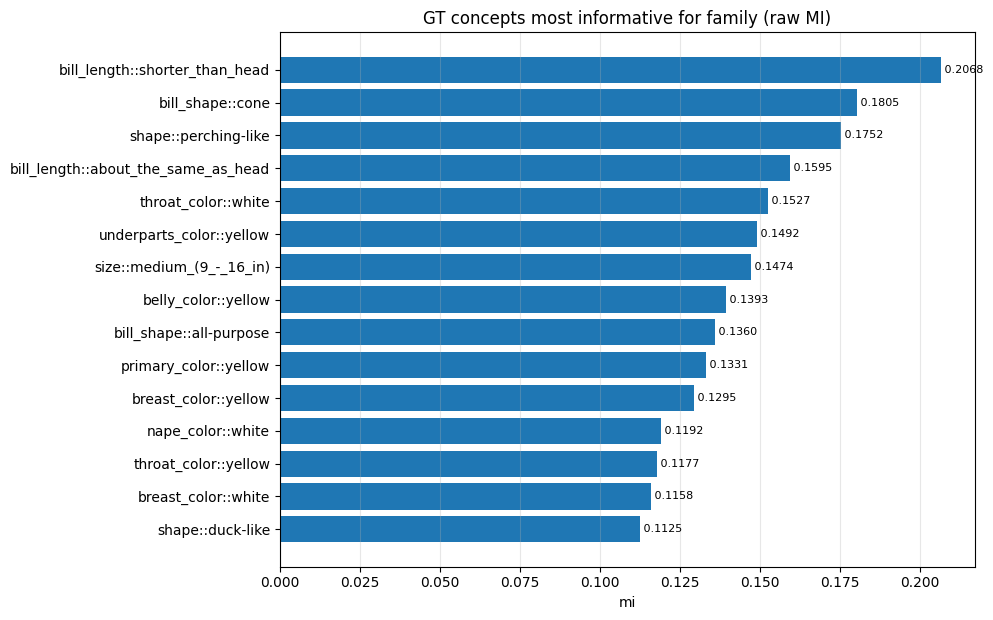

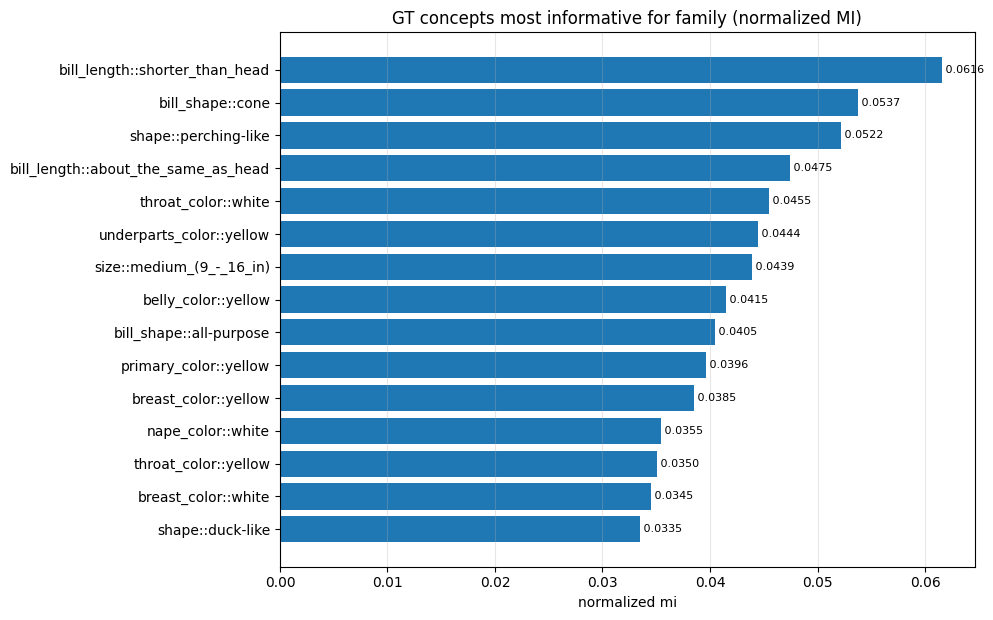


GT concepts: top concepts for genus


,rank,concept,part,region,mi,normalized_mi,n_samples,n_target_classes
0,1,has_bill_length::shorter_than_head,bill,head,0.23196,0.05488,5994,109
1,2,has_underparts_color::yellow,underparts,lower,0.20833,0.04929,5994,109
2,3,has_bill_shape::cone,bill,head,0.20390,0.04825,5994,109
3,4,has_primary_color::yellow,primary,other,0.19543,0.04624,5994,109
4,5,has_belly_color::yellow,belly,body,0.19478,0.04609,5994,109
5,6,has_bill_length::about_the_same_as_head,bill,head,0.19326,0.04573,5994,109
6,7,has_throat_color::white,throat,head,0.19177,0.04537,5994,109
7,8,has_shape::perching-like,shape,other,0.18843,0.04458,5994,109
8,9,has_breast_color::yellow,breast,body,0.18484,0.04373,5994,109
9,10,has_throat_color::yellow,throat,head,0.17215,0.04073,5994,109


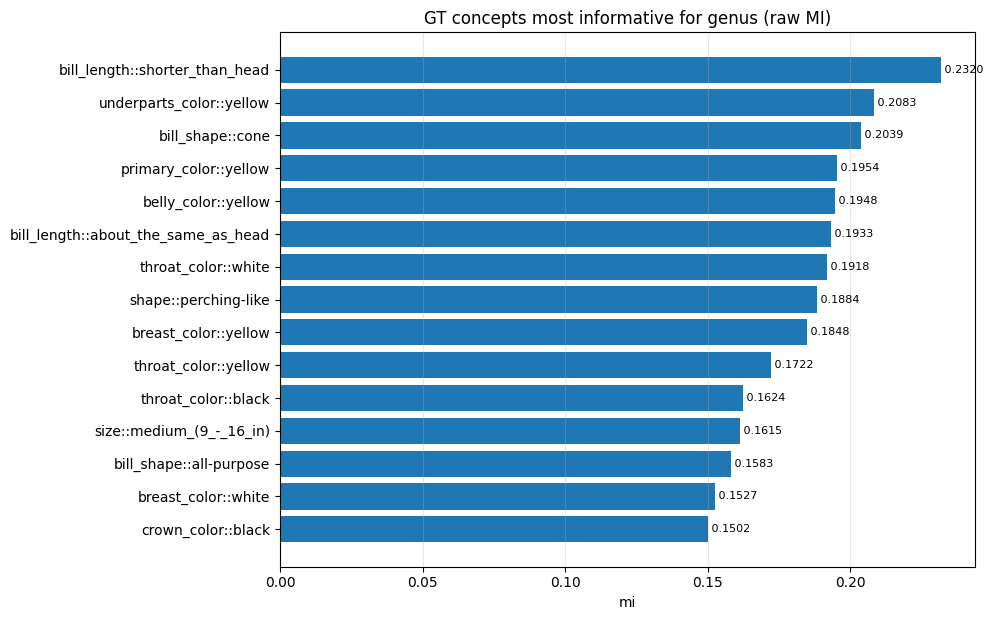

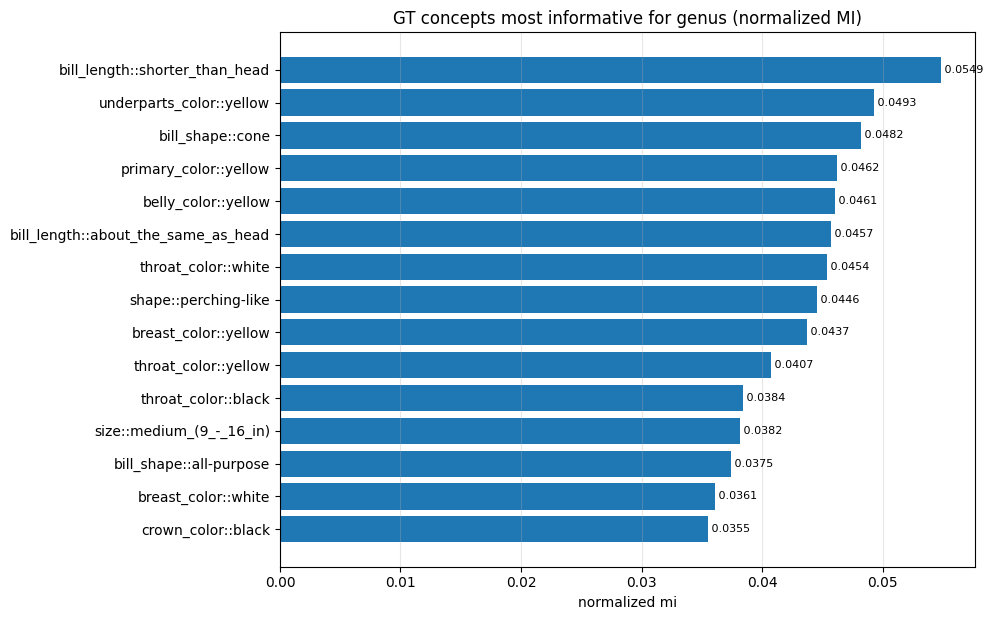


GT concepts: top concepts for species


,rank,concept,part,region,mi,normalized_mi,n_samples,n_target_classes
0,1,has_underparts_color::yellow,underparts,lower,0.26791,0.05056,5994,200
1,2,has_throat_color::white,throat,head,0.26232,0.04951,5994,200
2,3,has_belly_color::yellow,belly,body,0.25097,0.04737,5994,200
3,4,has_bill_length::shorter_than_head,bill,head,0.24975,0.04714,5994,200
4,5,has_breast_color::yellow,breast,body,0.24832,0.04687,5994,200
5,6,has_primary_color::yellow,primary,other,0.24281,0.04583,5994,200
6,7,has_throat_color::yellow,throat,head,0.24022,0.04534,5994,200
7,8,has_throat_color::black,throat,head,0.23405,0.04418,5994,200
8,9,has_breast_color::white,breast,body,0.22565,0.04259,5994,200
9,10,has_underparts_color::white,underparts,lower,0.22246,0.04199,5994,200


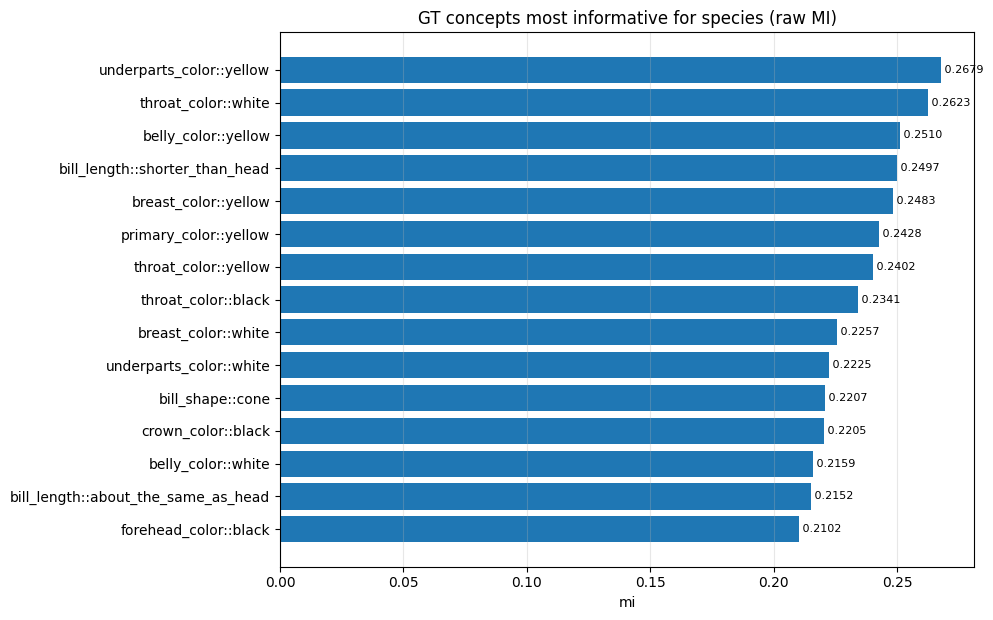

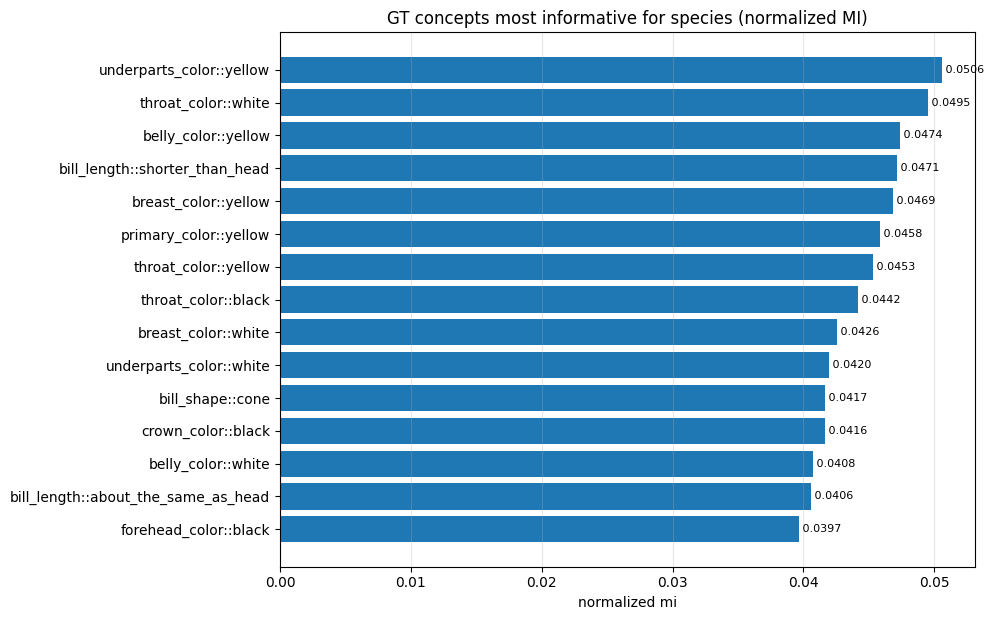


Concepts whose dataset-level normalized MI peaks at each taxonomy level:


,peak_level,region,part,n_concepts
3,family,head,bill,9
10,family,other,shape,7
11,family,other,size,5
5,family,head,eye,4
2,family,body,wing,3
4,family,head,crown,2
6,family,head,forehead,2
7,family,head,throat,2
0,family,body,belly,1
1,family,body,breast,1



GT concepts: strongest conditional concepts for genus within family


,rank,conditional_rank,concept,part,region,mi,normalized_mi,n_samples,n_target_classes,group_name,conditional_n_samples,conditional_n_classes
171,2,2,has_crown_color::black,crown,head,0.54700,0.78916,60,2,woodpecker,60,2
170,1,1,has_forehead_color::black,forehead,head,0.54700,0.78916,60,2,woodpecker,60,2
172,3,3,has_wing_color::white,wing,body,0.52560,0.75828,60,2,woodpecker,60,2
173,4,4,has_nape_color::black,nape,head,0.52560,0.75828,60,2,woodpecker,60,2
70,1,1,has_forehead_color::yellow,forehead,head,0.48789,0.70388,60,2,grosbeak,60,2
174,5,5,has_belly_pattern::spotted,belly,body,0.48789,0.70388,60,2,woodpecker,60,2
30,1,1,has_throat_color::yellow,throat,head,0.45666,0.28374,150,5,New World warbler,150,5
175,6,6,has_nape_color::white,nape,head,0.45531,0.65687,60,2,woodpecker,60,2
71,2,2,has_underparts_color::yellow,underparts,lower,0.42281,0.60999,60,2,grosbeak,60,2
176,7,7,has_belly_pattern::solid,belly,body,0.42281,0.60999,60,2,woodpecker,60,2



GT concepts: strongest conditional concepts for species within genus


,rank,conditional_rank,concept,part,region,mi,normalized_mi,n_samples,n_target_classes,group_name,conditional_n_samples,conditional_n_classes
110,1,1,has_forehead_color::black,forehead,head,0.56846,0.82011,60,2,grosbeak,60,2
10,1,1,has_throat_color::yellow,throat,head,0.52560,0.75828,60,2,New World goldfinch,60,2
111,2,2,has_crown_color::blue,crown,head,0.48789,0.70388,60,2,grosbeak,60,2
11,2,2,has_underparts_color::yellow,underparts,lower,0.48789,0.70388,60,2,New World goldfinch,60,2
12,3,3,has_nape_color::yellow,nape,head,0.48789,0.70388,60,2,New World goldfinch,60,2
112,3,3,has_primary_color::blue,primary,other,0.45531,0.65687,60,2,grosbeak,60,2
116,7,7,has_throat_color::blue,throat,head,0.45391,0.65486,60,2,grosbeak,60,2
13,4,4,has_breast_color::yellow,breast,body,0.45391,0.65486,60,2,New World goldfinch,60,2
113,4,4,has_belly_color::white,belly,body,0.45391,0.65486,60,2,grosbeak,60,2
114,5,5,has_nape_color::blue,nape,head,0.45391,0.65486,60,2,grosbeak,60,2



Overlap summary: global family top concepts vs conditional genus-within-family concepts


,count,mean,std,min,25%,50%,75%,max
jaccard_overlap,19.0,0.080137,0.074314,0.0,0.017241,0.071429,0.111111,0.25
n_shared_concepts,19.0,2.105263,1.852768,0.0,0.500000,2.000000,3.000000,6.00
conditional_top_k,19.0,10.000000,0.000000,10.0,10.000000,10.000000,10.000000,10.00



Overlap summary: global genus top concepts vs conditional species-within-genus concepts


,count,mean,std,min,25%,50%,75%,max
jaccard_overlap,26.0,0.123776,0.087703,0.0,0.071429,0.132479,0.153846,0.363636
n_shared_concepts,26.0,3.153846,2.013799,0.0,2.000000,3.500000,4.000000,8.000000
conditional_top_k,26.0,10.000000,0.000000,10.0,10.000000,10.000000,10.000000,10.000000


In [31]:
# ---------- Preliminary dataset-level discriminativeness using GT concepts ----------

if RUN_HIERARCHY_CONCEPT_RELEVANCE:
    taxonomy_df = add_taxonomy_columns(master_df)
    taxonomy_df.to_csv(os.path.join(EVAL_DIR, 'taxonomy_labels_for_analysis.csv'), index=False)

    taxonomy_summary = pd.DataFrame({
        'quantity': [
            'families', 'genera', 'species',
            'mean genera per family', 'mean species per genus', 'train images', 'test images'
        ],
        'value': [
            taxonomy_df['family_id'].nunique(),
            taxonomy_df['genus_id'].nunique(),
            taxonomy_df['species_id'].nunique(),
            taxonomy_df.groupby('family_id')['genus_id'].nunique().mean(),
            taxonomy_df.groupby('genus_id')['species_id'].nunique().mean(),
            int((taxonomy_df['is_train'] == 1).sum()),
            int((taxonomy_df['is_train'] == 0).sum()),
        ]
    })
    taxonomy_summary.to_csv(os.path.join(EVAL_DIR, 'taxonomy_dataset_summary.csv'), index=False)
    display(taxonomy_summary)

    train_tax = taxonomy_df[taxonomy_df['is_train'] == 1].copy()
    X_train_gt = concept_matrix.loc[train_tax['img_id'].values].values.astype(np.float32)
    y_family_train = train_tax['family_id'].values.astype(int)
    y_genus_train = train_tax['genus_id'].values.astype(int)
    y_species_train = train_tax['species_id'].values.astype(int)

    gt_mi_tables = {
        'family': compute_mi_table(X_train_gt, y_family_train, 'family', 'GT concepts / train split', discrete_features=True),
        'genus': compute_mi_table(X_train_gt, y_genus_train, 'genus', 'GT concepts / train split', discrete_features=True),
        'species': compute_mi_table(X_train_gt, y_species_train, 'species', 'GT concepts / train split', discrete_features=True),
    }

    gt_global_mi = pd.concat(gt_mi_tables.values(), ignore_index=True)
    gt_global_mi.to_csv(os.path.join(EVAL_DIR, 'gt_global_concept_mi_by_taxonomic_level.csv'), index=False)

    for level, df in gt_mi_tables.items():
        display_top_concepts(df, f'GT concepts: top concepts for {level}', n=MI_TOP_K)
        plot_top_concepts(df, f'GT concepts most informative for {level} (raw MI)', filename=f'gt_top_concepts_{level}.png', n=15, score_col='mi')
        plot_top_concepts(df, f'GT concepts most informative for {level} (normalized MI)', filename=f'gt_top_concepts_{level}_normalized.png', n=15, score_col='normalized_mi')

    gt_peak = cross_level_peak_table(gt_mi_tables, source_name='GT concepts / train split', score_col='normalized_mi')
    gt_peak.to_csv(os.path.join(EVAL_DIR, 'gt_concept_peak_taxonomic_level.csv'), index=False)
    print('\nConcepts whose dataset-level normalized MI peaks at each taxonomy level:')
    display(gt_peak.groupby(['peak_level', 'region', 'part']).size().reset_index(name='n_concepts').sort_values(['peak_level', 'n_concepts'], ascending=[True, False]).head(30))

    gt_family_to_genus_mi = conditional_top_mi_by_group(
        X_train_gt,
        coarse_labels=y_family_train,
        fine_labels=y_genus_train,
        coarse_level_name='family',
        fine_level_name='genus',
        source_name='GT concepts / train split',
        group_name_map=family_id_to_name,
        discrete_features=True,
    )
    gt_genus_to_species_mi = conditional_top_mi_by_group(
        X_train_gt,
        coarse_labels=y_genus_train,
        fine_labels=y_species_train,
        coarse_level_name='genus',
        fine_level_name='species',
        source_name='GT concepts / train split',
        group_name_map=genus_id_to_name,
        discrete_features=True,
    )

    gt_family_to_genus_mi.to_csv(os.path.join(EVAL_DIR, 'gt_conditional_family_to_genus_concept_mi.csv'), index=False)
    gt_genus_to_species_mi.to_csv(os.path.join(EVAL_DIR, 'gt_conditional_genus_to_species_concept_mi.csv'), index=False)

    display_top_concepts(gt_family_to_genus_mi.sort_values('mi', ascending=False), 'GT concepts: strongest conditional concepts for genus within family', n=30)
    display_top_concepts(gt_genus_to_species_mi.sort_values('mi', ascending=False), 'GT concepts: strongest conditional concepts for species within genus', n=30)

    gt_overlap_family_to_genus = summarize_conditional_overlap(
        gt_mi_tables['family'], gt_family_to_genus_mi,
        global_name='global family concepts',
        conditional_name='genus within family concepts',
        top_k=MI_TOP_K,
    )
    gt_overlap_genus_to_species = summarize_conditional_overlap(
        gt_mi_tables['genus'], gt_genus_to_species_mi,
        global_name='global genus concepts',
        conditional_name='species within genus concepts',
        top_k=MI_TOP_K,
    )
    gt_overlap_family_to_genus.to_csv(os.path.join(EVAL_DIR, 'gt_overlap_global_family_vs_conditional_genus.csv'), index=False)
    gt_overlap_genus_to_species.to_csv(os.path.join(EVAL_DIR, 'gt_overlap_global_genus_vs_conditional_species.csv'), index=False)

    print('\nOverlap summary: global family top concepts vs conditional genus-within-family concepts')
    display(overlap_numeric_summary(gt_overlap_family_to_genus))
    print('\nOverlap summary: global genus top concepts vs conditional species-within-genus concepts')
    display(overlap_numeric_summary(gt_overlap_genus_to_species))
else:
    print('Hierarchy-conditioned concept relevance analysis disabled.')


### 18.2 Prediction-level concept relevance

This part uses **predicted global CUB concepts** from the visual CBMs. It has two complementary views.

1. **Mutual information of predicted concepts with model decisions.** This asks which predicted concepts are most associated with the model's predicted family-like group, genus-like group, or species.
2. **Gradient relevance of taxonomic scores with respect to concepts.** This is more model-faithful: it differentiates the model's predicted family/genus/species probability with respect to the fine concept vector. For visual CBMs, family/genus probabilities are obtained by summing species probabilities over the corresponding taxonomy branch.

The WordNet-CBM is skipped here because it does not expose one shared 312-CUB-concept bottleneck. Its concept diagnostics are reported separately in the WordNet local concept-head quality section.


In [32]:
# ---------- Prediction-level concept relevance for visual CBMs ----------

def predicted_decision_mi_for_model(model_name, res):
    if res.get('fine_pred') is None:
        return {}, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    X_pred = res['fine_pred'].astype(np.float32)
    tables = {
        'pred_family': compute_mi_table(X_pred, res['pred_family'], 'predicted_family', f'{model_name} predicted concepts / test decisions', discrete_features=False),
        'pred_genus': compute_mi_table(X_pred, res['pred_genus'], 'predicted_genus', f'{model_name} predicted concepts / test decisions', discrete_features=False),
        'pred_species': compute_mi_table(X_pred, res['y_pred'], 'predicted_species', f'{model_name} predicted concepts / test decisions', discrete_features=False),
    }
    global_df = pd.concat(tables.values(), ignore_index=True)

    cond_family_to_genus = conditional_top_mi_by_group(
        X_pred,
        coarse_labels=res['pred_family'],
        fine_labels=res['pred_genus'],
        coarse_level_name='predicted_family',
        fine_level_name='predicted_genus',
        source_name=f'{model_name} predicted concepts / test decisions',
        group_name_map=family_id_to_name,
        discrete_features=False,
    )
    cond_genus_to_species = conditional_top_mi_by_group(
        X_pred,
        coarse_labels=res['pred_genus'],
        fine_labels=res['y_pred'],
        coarse_level_name='predicted_genus',
        fine_level_name='predicted_species',
        source_name=f'{model_name} predicted concepts / test decisions',
        group_name_map=genus_id_to_name,
        discrete_features=False,
    )
    return tables, global_df, cond_family_to_genus, cond_genus_to_species


# Masks that aggregate species probabilities into genus/family probabilities.
species_to_family_mask = torch.zeros(N_FAMILIES, N_CLASSES, dtype=torch.float32)
species_to_genus_mask = torch.zeros(N_GENERA, N_CLASSES, dtype=torch.float32)
for sid in range(N_CLASSES):
    species_to_family_mask[species_to_family[sid], sid] = 1.0
    species_to_genus_mask[species_to_genus[sid], sid] = 1.0
species_to_family_mask = species_to_family_mask.to(device)
species_to_genus_mask = species_to_genus_mask.to(device)


def concept_importance_by_taxonomic_score(model, fine_batch, target_ids, level):
    """Gradient × activation relevance of a taxonomic probability wrt fine concepts.

    level='species': target_ids are species IDs and score is P(species)
    level='genus'  : target_ids are genus IDs and score is sum P(species in genus)
    level='family' : target_ids are family IDs and score is sum P(species in family)
    """
    fine = fine_batch.clone().detach().to(device).requires_grad_(True)
    logits = classify_from_fine_concepts(model, fine)
    probs = torch.softmax(logits, dim=1)
    target_ids = target_ids.to(device).long()

    if level == 'species':
        score_per_sample = probs[torch.arange(probs.shape[0], device=device), target_ids]
    elif level == 'genus':
        masks = species_to_genus_mask[target_ids]
        score_per_sample = (probs * masks).sum(dim=1)
    elif level == 'family':
        masks = species_to_family_mask[target_ids]
        score_per_sample = (probs * masks).sum(dim=1)
    else:
        raise ValueError(level)

    model.zero_grad(set_to_none=True)
    score_per_sample.sum().backward()
    return (fine.grad.abs() * fine.detach()).detach()


def average_taxonomic_gradient_relevance(model, res, model_name, max_samples=RELEVANCE_MAX_SAMPLES):
    if res.get('fine_pred') is None or isinstance(model, WordNetCBM):
        return pd.DataFrame()
    n = len(res['fine_pred'])
    if max_samples is not None and max_samples < n:
        # Use deterministic sampling for reproducibility.
        rng = np.random.default_rng(SEED)
        idx_all = np.sort(rng.choice(n, size=max_samples, replace=False))
    else:
        idx_all = np.arange(n)

    fine_all = torch.tensor(res['fine_pred'][idx_all], dtype=torch.float32)
    target_map = {
        'family': torch.tensor(res['pred_family'][idx_all], dtype=torch.long),
        'genus': torch.tensor(res['pred_genus'][idx_all], dtype=torch.long),
        'species': torch.tensor(res['y_pred'][idx_all], dtype=torch.long),
    }

    rows = []
    for level, targets in target_map.items():
        total_imp = torch.zeros(N_CONCEPTS, dtype=torch.float32)
        total_n = 0
        for start in range(0, len(fine_all), BATCH_SIZE):
            end = start + BATCH_SIZE
            imp = concept_importance_by_taxonomic_score(
                model,
                fine_all[start:end].to(device),
                targets[start:end].to(device),
                level=level,
            ).detach().cpu()
            total_imp += imp.sum(dim=0)
            total_n += imp.shape[0]
        mean_imp = (total_imp / max(total_n, 1)).numpy()
        df = pd.DataFrame({
            'Model': model_name,
            'level': level,
            'concept_idx': np.arange(N_CONCEPTS, dtype=int),
            'concept': concept_names,
            'mean_grad_x_activation': mean_imp,
            'n_samples_used': total_n,
        }).sort_values('mean_grad_x_activation', ascending=False).reset_index(drop=True)
        df['rank'] = np.arange(1, len(df) + 1)
        df = add_concept_metadata(df)
        rows.append(df)
    return pd.concat(rows, ignore_index=True)


def relevance_overlap_across_levels(relevance_df, model_name, top_k=MI_TOP_K, score_col='mean_grad_x_activation'):
    if relevance_df is None or len(relevance_df) == 0:
        return pd.DataFrame()
    sets = {}
    for level in ['family', 'genus', 'species']:
        sub = relevance_df[relevance_df['level'] == level].sort_values(score_col, ascending=False)
        sets[level] = set(sub.head(top_k)['concept_idx'].astype(int))
    rows = []
    for a, b in [('family', 'genus'), ('genus', 'species'), ('family', 'species')]:
        rows.append({
            'Model': model_name,
            'level_a': a,
            'level_b': b,
            'top_k': top_k,
            'jaccard_overlap': jaccard(sets[a], sets[b]),
            'n_shared_concepts': len(sets[a] & sets[b]),
        })
    return pd.DataFrame(rows)


if RUN_HIERARCHY_CONCEPT_RELEVANCE:
    predicted_mi_global_rows = []
    predicted_mi_conditional_rows = []
    predicted_mi_overlap_rows = []
    gradient_relevance_rows = []
    gradient_overlap_rows = []

    for model_name, res in results.items():
        if res.get('fine_pred') is None:
            print(f'Prediction concept relevance skipped for {model_name}: no 312 CUB fine concept predictions are exposed.')
            continue

        print(f'\n=== Prediction-level relevance: {model_name} ===')
        mi_tables, global_df, cond_fam_gen, cond_gen_sp = predicted_decision_mi_for_model(model_name, res)
        predicted_mi_global_rows.append(global_df.assign(Model=model_name))
        if len(cond_fam_gen) > 0:
            predicted_mi_conditional_rows.append(cond_fam_gen.assign(Model=model_name))
        if len(cond_gen_sp) > 0:
            predicted_mi_conditional_rows.append(cond_gen_sp.assign(Model=model_name))

        for key, table in mi_tables.items():
            display_top_concepts(table, f'{model_name}: top predicted concepts associated with {key}', n=MI_TOP_K)

        ov1 = summarize_conditional_overlap(mi_tables['pred_family'], cond_fam_gen, 'predicted family', 'predicted genus within family', top_k=MI_TOP_K)
        ov2 = summarize_conditional_overlap(mi_tables['pred_genus'], cond_gen_sp, 'predicted genus', 'predicted species within genus', top_k=MI_TOP_K)
        if len(ov1) > 0:
            predicted_mi_overlap_rows.append(ov1.assign(Model=model_name))
        if len(ov2) > 0:
            predicted_mi_overlap_rows.append(ov2.assign(Model=model_name))

        # Gradient relevance of aggregated taxonomic probabilities wrt concepts.
        try:
            grad_df = average_taxonomic_gradient_relevance(models_to_eval[model_name], res, model_name, max_samples=RELEVANCE_MAX_SAMPLES)
            if len(grad_df) > 0:
                gradient_relevance_rows.append(grad_df)
                gradient_overlap_rows.append(relevance_overlap_across_levels(grad_df, model_name, top_k=MI_TOP_K))
                for level in ['family', 'genus', 'species']:
                    sub = grad_df[grad_df['level'] == level].sort_values('mean_grad_x_activation', ascending=False)
                    print(f'\n{model_name}: gradient relevance for predicted {level} probability')
                    display(sub.head(MI_TOP_K)[['rank', 'concept', 'part', 'region', 'mean_grad_x_activation', 'n_samples_used']].style.format({'mean_grad_x_activation': '{:.6f}'}))
        except Exception as e:
            print(f'Gradient relevance skipped for {model_name}: {e}')

    predicted_mi_global_df = pd.concat(predicted_mi_global_rows, ignore_index=True) if predicted_mi_global_rows else pd.DataFrame()
    predicted_mi_conditional_df = pd.concat(predicted_mi_conditional_rows, ignore_index=True) if predicted_mi_conditional_rows else pd.DataFrame()
    predicted_mi_overlap_df = pd.concat(predicted_mi_overlap_rows, ignore_index=True) if predicted_mi_overlap_rows else pd.DataFrame()
    gradient_relevance_df = pd.concat(gradient_relevance_rows, ignore_index=True) if gradient_relevance_rows else pd.DataFrame()
    gradient_overlap_df = pd.concat(gradient_overlap_rows, ignore_index=True) if gradient_overlap_rows else pd.DataFrame()

    predicted_mi_global_df.to_csv(os.path.join(EVAL_DIR, 'predicted_concept_global_mi_by_model.csv'), index=False)
    predicted_mi_conditional_df.to_csv(os.path.join(EVAL_DIR, 'predicted_concept_conditional_mi_by_model.csv'), index=False)
    predicted_mi_overlap_df.to_csv(os.path.join(EVAL_DIR, 'predicted_concept_mi_overlap_by_model.csv'), index=False)
    gradient_relevance_df.to_csv(os.path.join(EVAL_DIR, 'gradient_taxonomic_concept_relevance_by_model.csv'), index=False)
    gradient_overlap_df.to_csv(os.path.join(EVAL_DIR, 'gradient_taxonomic_relevance_overlap_by_model.csv'), index=False)

    print('\nPrediction MI overlap summary:')
    if len(predicted_mi_overlap_df) > 0:
        display(predicted_mi_overlap_df.groupby(['Model', 'global_reference', 'conditional_reference'])[['jaccard_overlap', 'n_shared_concepts']].agg(['mean', 'median', 'std', 'min', 'max']))
    else:
        print('No prediction MI overlap table available.')

    print('\nGradient relevance overlap across family/genus/species probabilities:')
    if len(gradient_overlap_df) > 0:
        display(gradient_overlap_df)
    else:
        print('No gradient relevance overlap table available.')
else:
    predicted_mi_global_df = pd.DataFrame()
    predicted_mi_conditional_df = pd.DataFrame()
    predicted_mi_overlap_df = pd.DataFrame()
    gradient_relevance_df = pd.DataFrame()
    gradient_overlap_df = pd.DataFrame()



=== Prediction-level relevance: Flat CBM ===

Flat CBM: top predicted concepts associated with pred_family


,rank,concept,part,region,mi,normalized_mi,n_samples,n_target_classes
0,1,has_bill_length::shorter_than_head,bill,head,0.59965,0.17919,5794,62
1,2,has_bill_length::about_the_same_as_head,bill,head,0.58827,0.17579,5794,62
2,3,has_shape::perching-like,shape,other,0.58051,0.17347,5794,62
3,4,has_size::medium_(9_-_16_in),size,other,0.53171,0.15889,5794,62
4,5,has_bill_shape::all-purpose,bill,head,0.53133,0.15878,5794,62
5,6,has_crown_color::white,crown,head,0.53012,0.15841,5794,62
6,7,has_head_pattern::eyering,head,head,0.52388,0.15655,5794,62
7,8,has_bill_shape::dagger,bill,head,0.52042,0.15551,5794,62
8,9,has_eye_color::black,eye,head,0.51454,0.15376,5794,62
9,10,has_upperparts_color::black,upperparts,body,0.51413,0.15363,5794,62



Flat CBM: top predicted concepts associated with pred_genus


,rank,concept,part,region,mi,normalized_mi,n_samples,n_target_classes
0,1,has_forehead_color::yellow,forehead,head,0.77361,0.18364,5794,109
1,2,has_bill_length::about_the_same_as_head,bill,head,0.76291,0.18110,5794,109
2,3,has_shape::perching-like,shape,other,0.75919,0.18022,5794,109
3,4,has_size::medium_(9_-_16_in),size,other,0.75407,0.17900,5794,109
4,5,has_crown_color::black,crown,head,0.75329,0.17882,5794,109
5,6,has_bill_length::shorter_than_head,bill,head,0.74542,0.17695,5794,109
6,7,has_upperparts_color::yellow,upperparts,body,0.74447,0.17672,5794,109
7,8,has_crown_color::white,crown,head,0.73490,0.17445,5794,109
8,9,has_head_pattern::capped,head,head,0.72693,0.17256,5794,109
9,10,has_throat_color::orange,throat,head,0.72089,0.17113,5794,109



Flat CBM: top predicted concepts associated with pred_species


...

,rank,concept,part,region,mean_grad_x_activation,n_samples_used
624,1,has_breast_pattern::solid,breast,body,0.016899,1024
625,2,has_back_pattern::solid,back,body,0.015549,1024
626,3,has_belly_pattern::solid,belly,body,0.015430,1024
627,4,has_wing_pattern::solid,wing,body,0.014538,1024
628,5,has_belly_color::white,belly,body,0.014493,1024
629,6,has_bill_color::black,bill,head,0.014141,1024
630,7,has_shape::perching-like,shape,other,0.013886,1024
631,8,has_throat_color::white,throat,head,0.013813,1024
632,9,has_breast_color::grey,breast,body,0.013558,1024
633,10,has_breast_color::white,breast,body,0.013542,1024


Prediction concept relevance skipped for WordNet Hier-CBM: no 312 CUB fine concept predictions are exposed.
Prediction concept relevance skipped for WordNet Hier-CBM (Beam-3): no 312 CUB fine concept predictions are exposed.
Prediction concept relevance skipped for WordNet Hier-CBM (Beam-5): no 312 CUB fine concept predictions are exposed.

Prediction MI overlap summary:


jaccard_overlap  \
                                                                              mean   
Model              global_reference conditional_reference                            
Flat CBM           predicted family predicted genus within family         0.033316   
                   predicted genus  predicted species within genus        0.016199   
Learnable Hier-CBM predicted family predicted genus within family         0.023278   
                   predicted genus  predicted species within genus        0.013452   
Mean Hier-CBM      predicted family predicted genus within family         0.017915   
                   predicted genus  predicted species within genus        0.028589   

                                                                              \
                                                                      median   
Model              global_reference conditional_reference                      
Flat CBM           predicted family predicted genus within family   0.034483   
                   predicted genus  predicted species within genus  0.000000   
Learnable Hier-CBM predicted family predicted genus within family   0.000000   
                   predicted genus  predicted species within genus  0.000000   
Mean Hier-CBM      predicted family predicted genus within family   0.000000   
                   predicted genus  predicted species within genus  0.000000   

                                                                              \
                                                                         std   
Model              global_reference conditional_reference                      
Flat CBM           predicted family predicted genus within family   0.027822   
                   predicted genus  predicted species within genus  0.024994   
Learnable Hier-CBM predicted family predicted genus within family   0.069558   
                   predicted genus  predicted species within genus  0.022480   
Mean Hier-CBM      predicted family predicted genus within family   0.047948   
                   predicted genus  predicted species within genus  0.041093   

                                                                         \
                                                                    min   
Model              global_reference conditional_reference                 
Flat CBM           predicted family predicted genus within family   0.0   
                   predicted genus  predicted species within genus  0.0   
Learnable Hier-CBM predicted family predicted genus within family   0.0   
                   predicted genus  predicted species within genus  0.0   
Mean Hier-CBM      predicted family predicted genus within family   0.0   
                   predicted genus  predicted species within genus  0.0   

                                                                              \
                                                                         max   
Model              global_reference conditional_reference                      
Flat CBM           predicted family predicted genus within family   0.071429   
                   predicted genus  predicted species within genus  0.071429   
Learnable Hier-CBM predicted family predicted genus within family   0.304348   
                   predicted genus  predicted species within genus  0.071429   
Mean Hier-CBM      predicted family predicted genus within family   0.200000   
                   predicted genus  predicted species within genus  0.153846   

                                                                   n_shared_concepts  \
                                                                                mean   
Model              global_reference conditional_reference                              
Flat CBM           predicted family predicted genus within family           0.947368   
                   predicted genus  predicted species within genus          0.461538   
Learnable Hie


Gradient relevance overlap across family/genus/species probabilities:


,Model,level_a,level_b,top_k,jaccard_overlap,n_shared_concepts
0,Flat CBM,family,genus,20,0.818182,18
1,Flat CBM,genus,species,20,0.739130,17
2,Flat CBM,family,species,20,0.600000,15
3,Mean Hier-CBM,family,genus,20,1.000000,20
4,Mean Hier-CBM,genus,species,20,0.818182,18
5,Mean Hier-CBM,family,species,20,0.818182,18
6,Learnable Hier-CBM,family,genus,20,0.904762,19
7,Learnable Hier-CBM,genus,species,20,0.818182,18
8,Learnable Hier-CBM,family,species,20,0.818182,18


### 18.3 How to read these tables

For the dataset-level MI tables:

- high **family MI** means the concept helps separate broad taxonomic groups;
- high **genus-within-family conditional MI** means the concept is useful only after the family is fixed;
- high **species-within-genus conditional MI** means the concept helps with very fine discrimination.

For the prediction-level tables:

- predicted-concept MI shows which concept predictions are associated with the model's decisions;
- gradient relevance is closer to faithfulness because it measures which concept scores locally affect the model's predicted taxonomic probability.

If family-level top concepts have low overlap with genus/species-level top concepts, then the hierarchy is producing different explanation granularity rather than repeating the same evidence at every level.

## 19. Summary dashboard

The final table combines predictive performance, concept quality, hierarchy consistency, mistake severity, and faithfulness.

In [33]:
summary = perf_df.copy()
summary = summary.merge(concept_df, on='Model', how='left')
if len(consistency_df) > 0:
    consistency_cols = ['Model', 'Overall Binary Violation', 'Overall Soft Violation', 'Mean Part Score', 'Mean Region Score']
    summary = summary.merge(consistency_df[consistency_cols], on='Model', how='left')
summary = summary.merge(
    mistake_df[['Model', 'Taxonomy Source', 'Mean Severity Wrong Only', 'Median Severity Wrong Only',
                'Same-Genus Error %', 'Same-Family Error %', 'Different-Family Error %']],
    on='Model', how='left'
)

# Add Drop@10 if concept removal was computed.
drop_rows = []
for name, df in removal_results.items():
    if 0 in set(df['k_removed']) and 10 in set(df['k_removed']):
        acc0 = float(df.loc[df['k_removed'] == 0, 'accuracy'].iloc[0])
        acc10 = float(df.loc[df['k_removed'] == 10, 'accuracy'].iloc[0])
        drop_rows.append({'Model': name, 'Accuracy Drop@10 Removed': acc0 - acc10})
if drop_rows:
    summary = summary.merge(pd.DataFrame(drop_rows), on='Model', how='left')

# Add calibrated oracle delta if available.
intervention_delta_rows = []
for name, df in intervention_results.items():
    try:
        base = float(df.loc[df['Setting'] == 'predicted fine concepts (in-distribution)', 'Accuracy'].iloc[0])
        cal = float(df.loc[df['Setting'] == 'calibrated oracle concepts (less OOD)', 'Accuracy'].iloc[0])
        raw = float(df.loc[df['Setting'] == 'raw binary GT concepts (OOD diagnostic)', 'Accuracy'].iloc[0])
        intervention_delta_rows.append({
            'Model': name,
            'Calibrated Oracle ΔAcc': cal - base,
            'Raw Binary GT Diagnostic ΔAcc': raw - base,
        })
    except Exception:
        pass
if intervention_delta_rows:
    summary = summary.merge(pd.DataFrame(intervention_delta_rows), on='Model', how='left')

# Add WordNet oracle-routing and local concept summaries as model-level context.
if 'oracle_routing_df' in globals() and len(oracle_routing_df) > 0:
    oracle_wide = {row['Diagnostic']: row['Accuracy'] for _, row in oracle_routing_df.iterrows()}
    for k, v in oracle_wide.items():
        summary.loc[summary['Model'] == 'WordNet Hier-CBM', f'WordNet {k}'] = v
if 'local_concept_quality_df' in globals() and len(local_concept_quality_df) > 0:
    for _, row in local_concept_quality_df.iterrows():
        level = row['Level']
        summary.loc[summary['Model'] == 'WordNet Hier-CBM', f'{level} Acc'] = row['Accuracy']
        summary.loc[summary['Model'] == 'WordNet Hier-CBM', f'{level} Balanced Acc'] = row['Balanced Accuracy']

summary_path = os.path.join(EVAL_DIR, 'final_summary.csv')
summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
display(summary.style.format({c: '{:.4f}' for c in summary.columns if c not in ['Model', 'Taxonomy Source']}, na_rep='N/A'))


Saved: c:\Users\elzia\Documents\torino\polito\05_semestre2\explainable_trustworthy_ai\progetto\github\ETAI-2025-26\processed\final_evaluation\final_summary.csv


,Model,Top-1 Acc,Top-5 Acc,Macro-F1,Weighted-F1,Balanced Acc,Genus Acc,Family Acc,Fine Acc,Fine Macro-F1,Fine Balanced Acc,Fine BalAcc undefined #,Part Strength Acc,Part Strength F1,Part Strength MAE,Region Strength Acc,Region Strength F1,Region Strength MAE,Part Presence Acc Diagnostic,Region Presence Acc Diagnostic,Overall Binary Violation,Overall Soft Violation,Mean Part Score,Mean Region Score,Taxonomy Source,Mean Severity Wrong Only,Median Severity Wrong Only,Same-Genus Error %,Same-Family Error %,Different-Family Error %,Accuracy Drop@10 Removed,Calibrated Oracle ΔAcc,Raw Binary GT Diagnostic ΔAcc,WordNet Greedy species accuracy,WordNet True family-like -> predicted genus-like accuracy,WordNet True family-like -> predicted genus-like -> species accuracy,WordNet True family-like + true genus-like -> species accuracy,root local concepts Acc,root local concepts Balanced Acc,family-local concepts Acc,family-local concepts Balanced Acc,genus-local concepts Acc,genus-local concepts Balanced Acc
0,Flat CBM,0.8010,0.9556,0.8027,0.8014,0.8023,0.8661,0.8890,0.8133,0.2042,0.5938,0.0000,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,WordNet family-like/genus-like + fallback,2.2220,3.0000,0.3270,0.1240,0.5490,0.0276,-0.7772,-0.7397,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,WordNet Hier-CBM (Beam-5),0.8005,0.9468,0.8001,0.7991,0.8016,0.8630,0.8868,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,WordNet family-like/genus-like + fallback,2.2500,3.0000,0.3131,0.1237,0.5631,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,WordNet Hier-CBM (Beam-3),0.8001,0.9363,0.7998,0.7988,0.8013,0.8626,0.8864,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,WordNet family-like/genus-like + fallback,2.2513,3.0000,0.3126,0.1235,0.5639,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,WordNet Hier-CBM,0.7913,0.8519,0.7902,0.7893,0.7925,0.8562,0.8816,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,WordNet family-like/genus-like + fallback,2.2523,3.0000,0.3110,0.1257,0.5633,N/A,N/A,N/A,0.7913,0.9625,0.8864,0.9184,0.6469,0.6207,0.6890,0.6274,0.7072,0.6435
4,Learnable Hier-CBM,0.7289,0.9303,0.7300,0.7285,0.7306,0.8093,0.8410,0.8818,0.2351,0.6040,0.0000,1.0000,0.0000,0.3768,1.0000,0.0000,0.2479,0.1256,0.0451,0.0555,0.0726,0.4720,0.3443,WordNet family-like/genus-like + fallback,2.2864,3.0000,0.2966,0.1203,0.5831,0.2114,-0.7045,-0.6381,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
5,Mean Hier-CBM,0.6367,0.9108,0.6099,0.6095,0.6369,0.7451,0.7851,0.6832,0.1404,0.5195,0.0000,0.6786,0.0001,0.2749,0.8813,0.0000,0.2237,0.3731,0.1546,0.1357,0.0742,0.3082,0.3089,WordNet family-like/genus-like + fallback,2.2888,3.0000,0.2983,0.1145,0.5872,0.0942,-0.6312,-0.6307,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
